## Import

In [1]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV 

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, max_error

import pandas as pd

In [2]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from ML.utils.Model_trainer import Model_trainer
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [3]:
pre_path = "../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_B/fine_tuned_models/"
path_to_predictions = pre_path + "predictions/model_B/fine_tuned_models/"
tag = "mass_smaller_14"
output_parameters = ['T_eff', 'log_g', 'radius']
categories_name = ["phase"]

In [4]:
override = True
use_preds = False
save = True
show = True

In [5]:
def display_grid_search(gscv):
    df = pd.DataFrame.from_dict(gscv.cv_results_)
    pd.set_option('display.max_columns', None)
    display(df)
    print(f"Best parameters {gscv.best_params_}")
    print(f"Best score {gscv.best_score_}")

## Data preparation

In [6]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()

Reading MIST dataframe from MIST_reclassified_iso_full_data.csv file...


In [7]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3], 'star_mass':('<', 14)})

In [8]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'metallicity', 'star_mass'], 
                               y_cols=['log_Teff', 'log_g', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the log_Teff parameter : 3.344668191350628 - 4.634489491902143
Median value in train data for the log_Teff parameter: 3.8641118622993966
Mean value in train data for the log_Teff parameter: 3.9345581069095505

Range in train data for the log_g parameter : -1.0828963170617296 - 5.433094523832443
Median value in train data for the log_g parameter: 3.9484790508590737
Mean value in train data for the log_g parameter: 3.548006174763417

Range in train data for the log_R parameter : -0.9974747647513328 - 3.082068881511837
Median value in train data for the log_R parameter: 0.5381900688843242
Mean value in train data for the log_R parameter: 0.6069651248403705

Testing set statistics:
Range in test data for the log_Teff parameter : 3.344711147414537 - 4.633956017110521
Median value in test data for the log_Teff parameter: 3.865317881638998
Mean value in test data for the log_Teff parameter: 3.9346904482232112

Range in test data for the log_g p

# Faire le fine-tuning avec mass_smaller_14 et random_forest, KNN, decision tree

## Fine-tuning

### Decision tree

#### Tuning the criterion and splitter parameter

In [9]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'criterion' : ["squared_error", "friedman_mse"], # absolute_error prend beaucoup de temps et poisson n'est pas possible avec des valeurs négatives
             'splitter' : ["best", "random"]
            }

gscv_dt_1 = GridSearchCV(DecisionTreeRegressor(),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         n_jobs = 10,
                         refit="neg_root_mean_squared_error"
)

gscv_dt_1.fit(X_train,y_train)
display_grid_search(gscv_dt_1)

Fitting 10 folds for each of 4 candidates, totalling 40 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_splitter,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,2.306406,0.049175,0.042283,0.005998,squared_error,best,"{'criterion': 'squared_error', 'splitter': 'be...",-0.350986,-0.350334,-0.352408,-0.348978,-0.347947,-0.344510,-0.340848,-0.343228,-0.350062,-0.355456,-0.348476,0.004224,4,-0.097317,-0.096377,-0.097399,-0.095364,-0.095436,-0.094895,-0.092961,-0.093596,-0.096692,-0.098921,-0.095896,0.001723,4
1,0.957149,0.028963,0.049660,0.007446,squared_error,random,"{'criterion': 'squared_error', 'splitter': 'ra...",-0.351370,-0.348208,-0.349693,-0.344765,-0.345209,-0.341467,-0.334042,-0.334600,-0.349180,-0.351466,-0.345000,0.006107,2,-0.095460,-0.093952,-0.094534,-0.092314,-0.092479,-0.092126,-0.088788,-0.088404,-0.094341,-0.095330,-0.092773,0.002375,2
2,2.006045,0.037707,0.041331,0.008543,friedman_mse,best,"{'criterion': 'friedman_mse', 'splitter': 'best'}",-0.346530,-0.350096,-0.351205,-0.347355,-0.348241,-0.341690,-0.339594,-0.342558,-0.352691,-0.354214,-0.347417,0.004633,3,-0.096052,-0.096481,-0.097171,-0.094907,-0.096038,-0.094435,-0.092519,-0.093430,-0.097675,-0.098566,-0.095727,0.001806,3
3,0.846737,0.021723,0.034554,0.008910,friedman_mse,random,"{'criterion': 'friedman_mse', 'splitter': 'ran...",-0.350532,-0.345048,-0.347561,-0.345300,-0.345407,-0.339938,-0.340460,-0.333939,-0.346950,-0.348223,-0.344336,0.004645,1,-0.095196,-0.093003,-0.094086,-0.092604,-0.092507,-0.091188,-0.091552,-0.088602,-0.093740,-0.094417,-0.092689,0.001809,1


Best parameters {'criterion': 'friedman_mse', 'splitter': 'random'}
Best score -0.3443358599453066


#### Tuning the max_depth, min_samples_split and min_samples_leaf parameter

In [ ]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'max_depth' : [25, 50, 75, 100, None],
             'min_samples_split' : [2, 4, 6, 8, 10],
             'min_samples_leaf' : [1, 2, 3, 4, 5],
            }

gscv_dt_2 = GridSearchCV(DecisionTreeRegressor(criterion="squared_error",
                                               splitter="best"
                                               ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         n_jobs = 10,
                         refit="neg_root_mean_squared_error"
)

gscv_dt_2.fit(X_train,y_train)
display_grid_search(gscv_dt_2)

Fitting 10 folds for each of 125 candidates, totalling 1250 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,2.213278,0.034519,0.032539,0.006780,25,1,2,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.028956,-0.030055,-0.029111,-0.027573,-0.032414,-0.031799,-0.030536,-0.028696,-0.029310,-0.030272,-0.029872,0.001386,1,-0.010808,-0.010888,-0.010700,-0.010439,-0.010940,-0.010804,-0.010788,-0.010808,-0.010699,-0.010964,-0.010784,0.000142,1
1,2.044078,0.027852,0.023129,0.004908,25,1,4,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.030226,-0.030879,-0.030125,-0.029141,-0.033861,-0.032607,-0.031859,-0.029737,-0.030372,-0.030529,-0.030934,0.001361,9,-0.011638,-0.011717,-0.011558,-0.011319,-0.011817,-0.011666,-0.011677,-0.011630,-0.011571,-0.011741,-0.011634,0.000128,7
2,1.949111,0.037430,0.018669,0.003764,25,1,6,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.031871,-0.032242,-0.031722,-0.030358,-0.035455,-0.033936,-0.033474,-0.031440,-0.032195,-0.032781,-0.032547,0.001366,28,-0.012831,-0.012880,-0.012704,-0.012472,-0.013017,-0.012814,-0.012869,-0.012813,-0.012801,-0.012910,-0.012811,0.000137,23
3,1.862920,0.043967,0.016021,0.001433,25,1,8,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.033341,-0.034005,-0.033439,-0.032175,-0.037237,-0.035246,-0.034782,-0.033198,-0.033850,-0.033988,-0.034126,0.001313,46,-0.013966,-0.014146,-0.013978,-0.013648,-0.014232,-0.014016,-0.014028,-0.014048,-0.014059,-0.014165,-0.014029,0.000151,47
4,1.836903,0.022301,0.017079,0.003322,25,1,10,"{'max_depth': 25, 'min_samples_leaf': 1, 'min_...",-0.035023,-0.035496,-0.035028,-0.034145,-0.038587,-0.036713,-0.036578,-0.035017,-0.035772,-0.035677,-0.035804,0.001178,82,-0.015194,-0.015191,-0.015153,-0.014738,-0.015436,-0.015063,-0.015211,-0.015183,-0.015260,-0.015363,-0.015179,0.000178,82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,1.752631,0.047312,0.013315,0.001081,None,5,2,"{'max_depth': None, 'min_samples_leaf': 5, 'mi...",-0.036103,-0.036733,-0.037507,-0.035491,-0.039934,-0.037413,-0.036844,-0.036980,-0.037810,-0.037240,-0.037206,0.001118,109,-0.015941,-0.016040,-0.016040,-0.015559,-0.016135,-0.015810,-0.015917,-0.016238,-0.016165,-0.016204,-0.016005,0.000197,107
121,1.763237,0.036337,0.013714,0.001272,None,5,4,"{'max_depth': None, 'min_samples_leaf': 5, 'mi...",-0.036232,-0.036807,-0.037521,-0.035574,-0.037668,-0.037393,-0.036777,-0.036984,-0.037992,-0.037110,-0.037006,0.000677,102,-0.015965,-0.016046,-0.016030,-0.015565,-0.016108,-0.015808,-0.015897,-0.016250,-0.016190,-0.016196,-0.016005,0.000197,109
122,1.761925,0.040997,0.012813,0.001006,None,5,6,"{'max_depth': None, 'min_samples_leaf': 5, 'mi...",-0.036060,-0.036775,-0.037505,-0.035576,-0.039791,-0.037426,-0.036766,-0.036927,-0.037984,-0.037199,-0.037201,0.001089,108,-0.015942,-0.016043,-0.016038,-0.015558,-0.016134,-0.015814,-0.015903,-0.016238,-0.016179,-0.016210,-0.016006,0.000199,110
123,1.764004,0

Best parameters {'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best score -0.029872075913069174


#### Tuning the max_features and max_leaf_nodes parameter

In [ ]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'max_features' : ["sqrt", "log2", None],
             'max_leaf_nodes' : [50, 100, 150, 200, None]
            }

gscv_dt_3 = GridSearchCV(DecisionTreeRegressor(criterion="squared_error",
                                               splitter="best",
                                               max_depth=25,
                                               min_samples_leaf=1,
                                               min_samples_split=2
                                               ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         n_jobs = 10,
                         refit="neg_root_mean_squared_error"
)

gscv_dt_3.fit(X_train,y_train)
display_grid_search(gscv_dt_3)

Fitting 10 folds for each of 15 candidates, totalling 150 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_max_leaf_nodes,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,2.272010,0.192044,0.023115,0.004273,sqrt,50,"{'max_features': 'sqrt', 'max_leaf_nodes': 50}",-0.427291,-0.487262,-0.511141,-0.425901,-0.490572,-0.425705,-0.430462,-0.410554,-0.409313,-0.402227,-0.442043,0.037016,14,-0.285615,-0.333045,-0.344559,-0.301719,-0.331953,-0.297863,-0.299326,-0.291873,-0.287776,-0.282599,-0.305633,0.021247,14
1,3.067361,0.237731,0.022029,0.003252,sqrt,100,"{'max_features': 'sqrt', 'max_leaf_nodes': 100}",-0.422417,-0.315106,-0.357964,-0.360439,-0.373223,-0.387265,-0.330822,-0.369188,-0.310071,-0.372276,-0.359877,0.032269,12,-0.261546,-0.213286,-0.246529,-0.238787,-0.257654,-0.256890,-0.224954,-0.261588,-0.218424,-0.252700,-0.243236,0.017417,11
2,3.191271,0.295865,0.026823,0.007163,sqrt,150,"{'max_features': 'sqrt', 'max_leaf_nodes': 150}",-0.294236,-0.305122,-0.293575,-0.338198,-0.281868,-0.288135,-0.266412,-0.302517,-0.354515,-0.318001,-0.304258,0.025057,10,-0.200372,-0.202284,-0.205598,-0.227872,-0.191966,-0.199954,-0.179370,-0.204204,-0.216237,-0.214321,-0.204218,0.012697,10
3,3.278920,0.300051,0.022978,0.004777,sqrt,200,"{'max_features': 'sqrt', 'max_leaf_nodes': 200}",-0.267184,-0.241701,-0.264172,-0.263859,-0.265695,-0.278046,-0.262265,-0.319999,-0.280244,-0.261848,-0.270501,0.019216,6,-0.181749,-0.164650,-0.177594,-0.181586,-0.180141,-0.186427,-0.179774,-0.209802,-0.192885,-0.177813,-0.183242,0.011145,6
4,5.645952,0.190538,0.077853,0.008066,sqrt,None,"{'max_features': 'sqrt', 'max_leaf_nodes': None}",-0.045431,-0.052487,-0.047546,-0.044302,-0.042671,-0.042848,-0.040897,-0.043734,-0.048470,-0.040269,-0.044866,0.003549,2,-0.015704,-0.016058,-0.015532,-0.015254,-0.015459,-0.015311,-0.015207,-0.016043,-0.016431,-0.014817,-0.015581,0.000458,2
5,2.090575,0.249706,0.016816,0.002947,log2,50,"{'max_features': 'log2', 'max_leaf_nodes': 50}",-0.519779,-0.499217,-0.399534,-0.411406,-0.403811,-0.596255,-0.423208,-0.516681,-0.429595,-0.426634,-0.462612,0.062760,15,-0.342108,-0.337606,-0.270650,-0.279981,-0.283883,-0.386734,-0.288485,-0.320175,-0.308568,-0.312122,-0.313031,0.033606,15
6,2.380916,0.121383,0.019529,0.003077,log2,100,"{'max_features': 'log2', 'max_leaf_nodes': 100}",-0.374457,-0.346436,-0.387565,-0.369110,-0.335795,-0.340231,-0.322133,-0.368841,-0.333416,-0.404698,-0.358268,0.025297,11,-0.255580,-0.229007,-0.261484,-0.255352,-0.231462,-0.224566,-0.220732,-0.259828,-0.239966,-0.265628,-0.244360,0.016134,12
7,2.507366,0.193392,0.018474,0.001926,log2,150,"{'max_features': 'log2', 'max_leaf_nodes': 150}",-0.277385,-0.295420,-0.279581,-0.303520,-0.309885,-0.262043,-0.297494,-0.342597,-0.254606,-0.305404,-0.292793,0.024272,9,-0.194676,-0.193338,-0.195446,-0.197701,-0.211413,-0.181332,-0.204034,-0.223784,-0.176020,-0.198665,-0.197641,0.012964,9
8,2.535707,0.129375,0.017007,0.002258,log2,200,"{'max_features': 'log2', 'max_leaf_nodes': 200}",-0.291096,-0.276342,-0.325094,-0.278117,-0.255932,-0.236204,-0.295969,-0.309684,-0.264343,-0.297958,-0.

Best parameters {'max_features': None, 'max_leaf_nodes': None}
Best score -0.029912831791745476


ccp_alpha met trop longtemps (20 minutes pour 1 split de K-fold)

#### Training the model with all the fine-tuned parameters and checking the results

../../../../../../results/model_A_partial/fine_tuned_models/

mass_smaller_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9997614611779155
  RMSE :  0.05089754966535651
  MAE :  0.01694664223969445
  MedAE :  0.004121444107862526
  CORR :  0.999880726193481
  MAX_ER :  5.054212555120426
  Percentiles : 
    75th percentile :  0.013617205677757704
    90th percentile :  0.042039684345619444
    95th percentile :  0.07396634199397914
    99th percentile :  0.19481065075139695

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9999389679303181
  RMSE :  0.025386447817606496
  MAE :  0.007701050580062739
  MedAE :  0.00032602915687751644
  CORR :  0.9999696236150757
  MAX_ER :  1.4112652929022005
  Percentiles : 
    75th percentile :  0.0057824807320

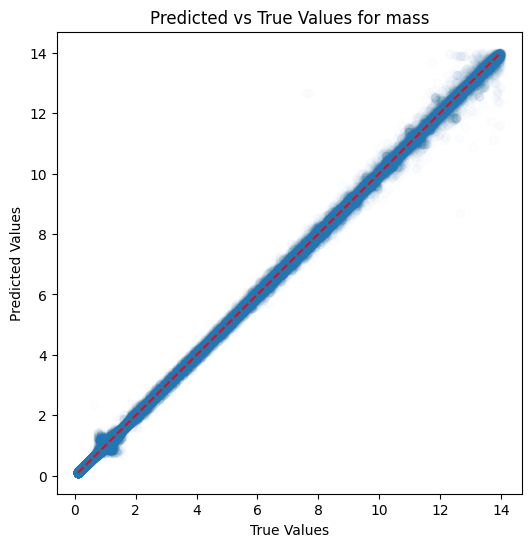

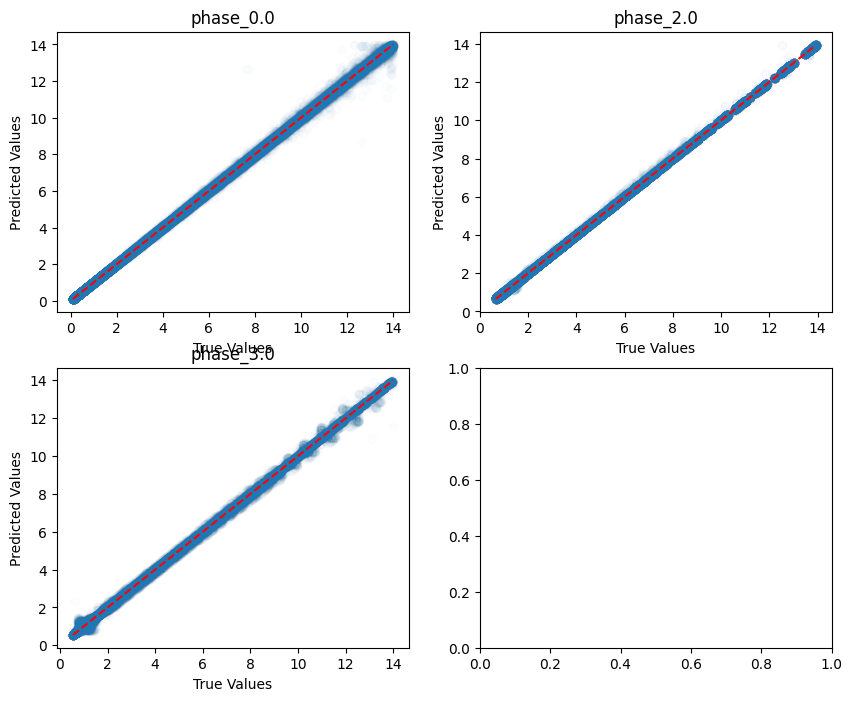

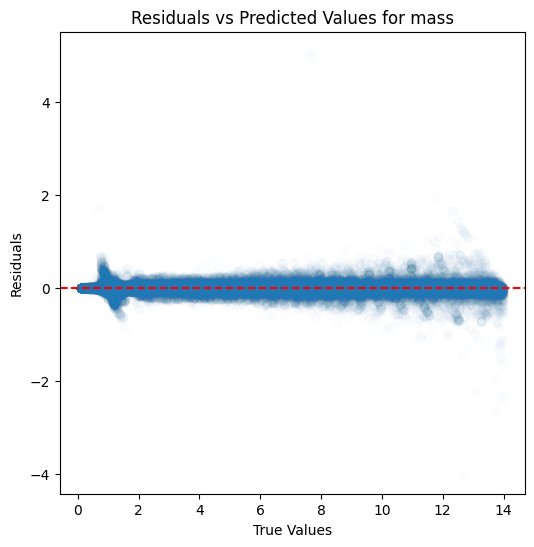

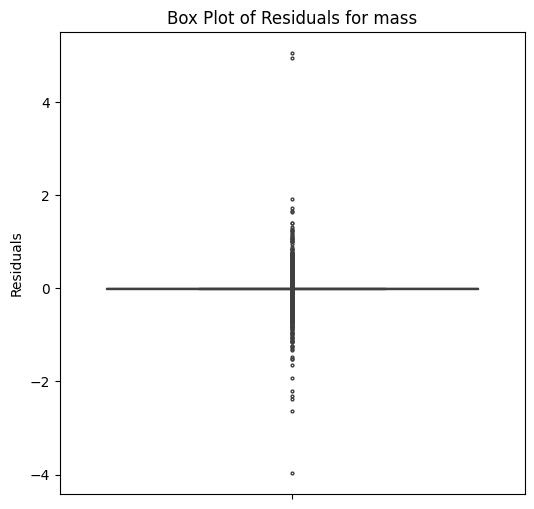

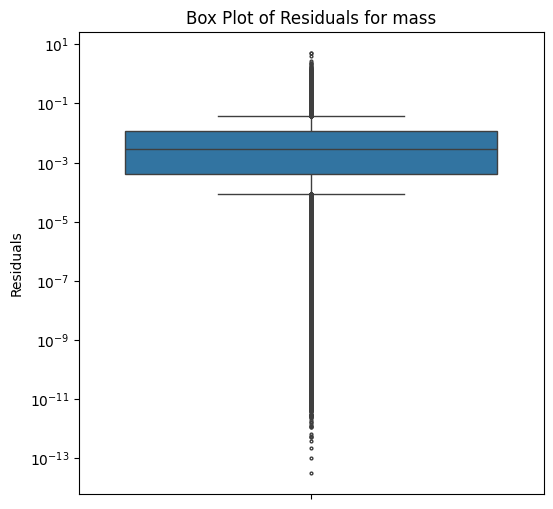

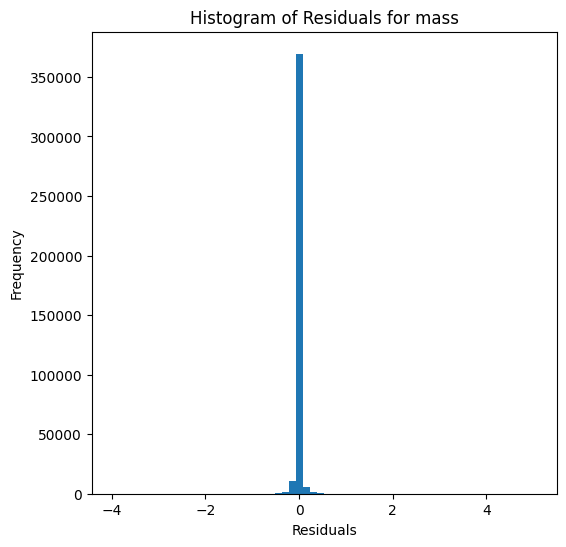

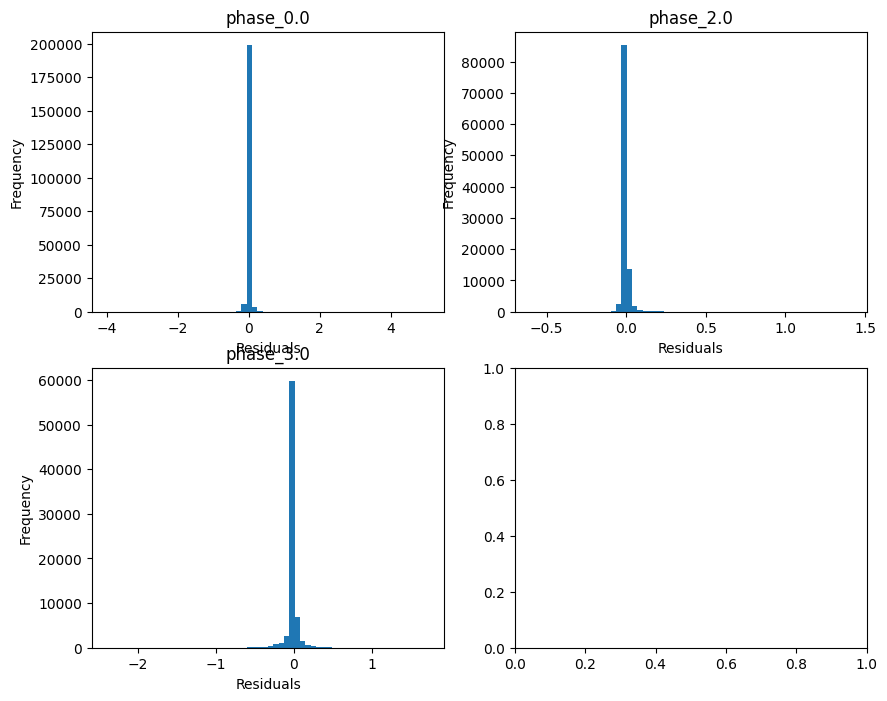

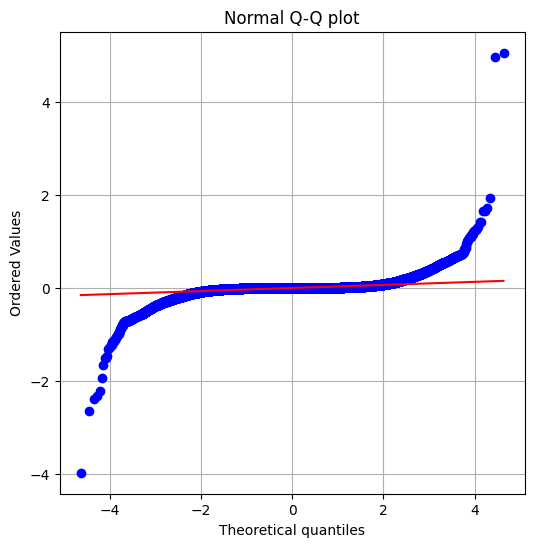

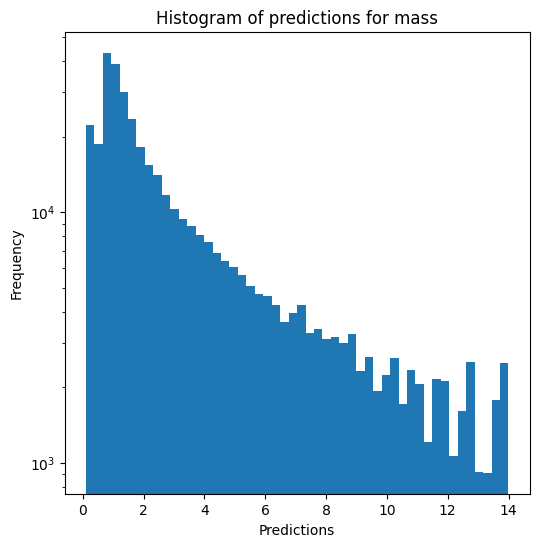

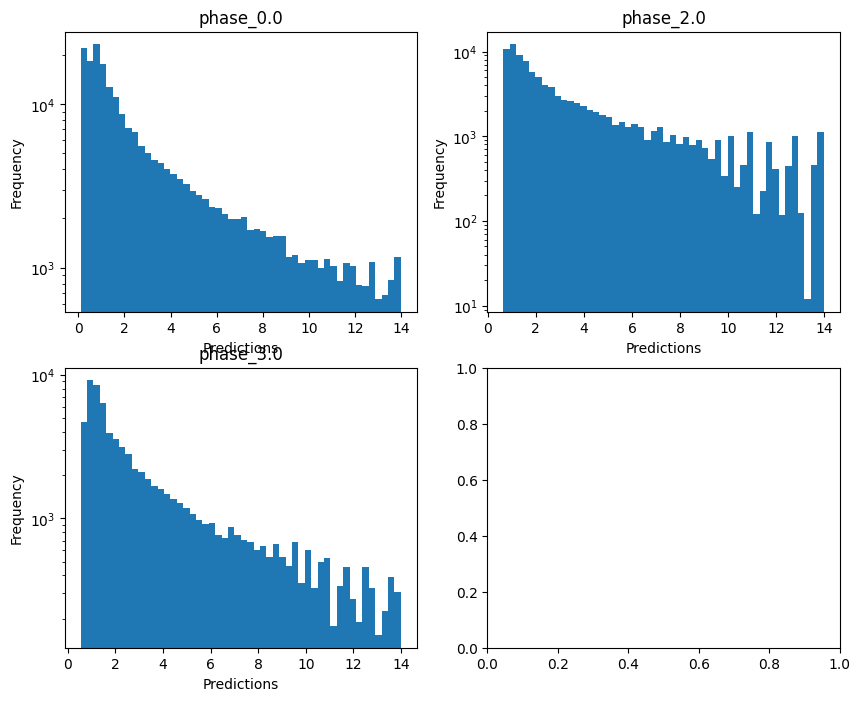

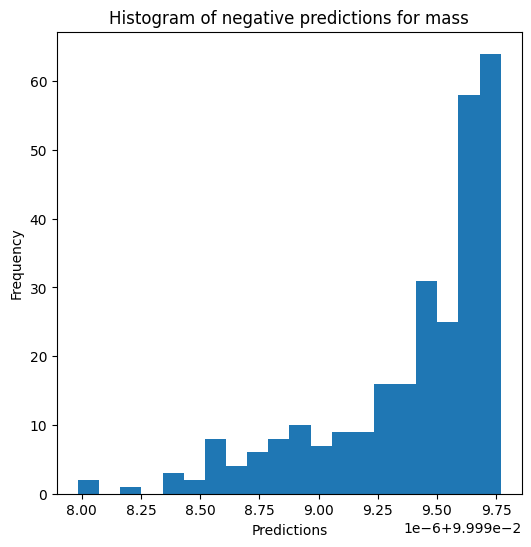


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9997874932846229
  RMSE :  0.006144428762110296
  MAE :  0.0036406029320289576
  MedAE :  0.002285351089456711
  CORR :  0.9998937426650212
  MAX_ER :  0.3111731559611798
  Percentiles : 
    75th percentile :  0.004563481950735748
    90th percentile :  0.008074220693299007
    95th percentile :  0.01132062222313459
    99th percentile :  0.02403872156468691

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9994893968097667
  RMSE :  0.010527857204866308
  MAE :  0.007358753787261535
  MedAE :  0.006039373792473768
  CORR :  0.9997470078767473
  MAX_ER :  0.445657670892194
  Percentiles : 
    75th percentile :  0.00984488171734299
    90th percentile :  0.013844677350365764
    95th percentile :  0.01724115656205516
    99th percentile :  0.03212969195286108

radius results for the p

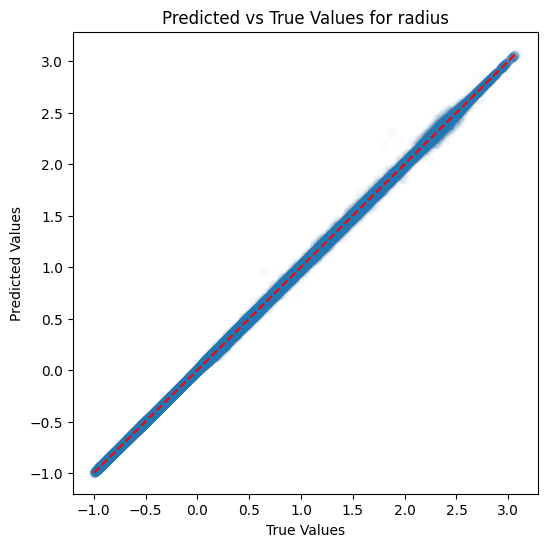

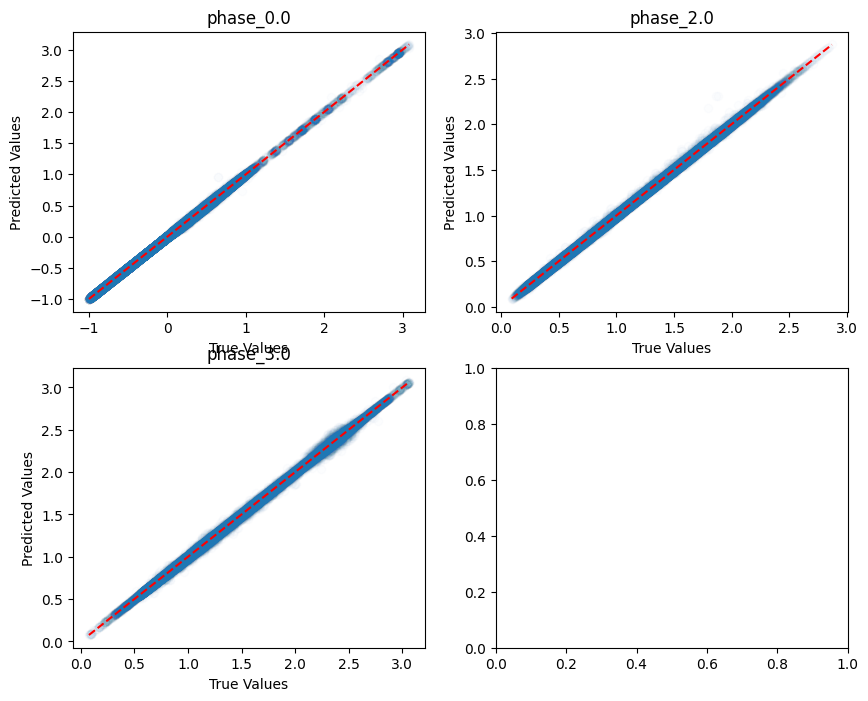

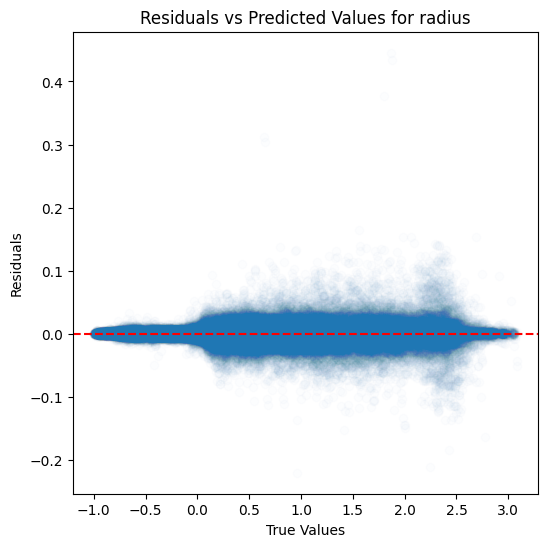

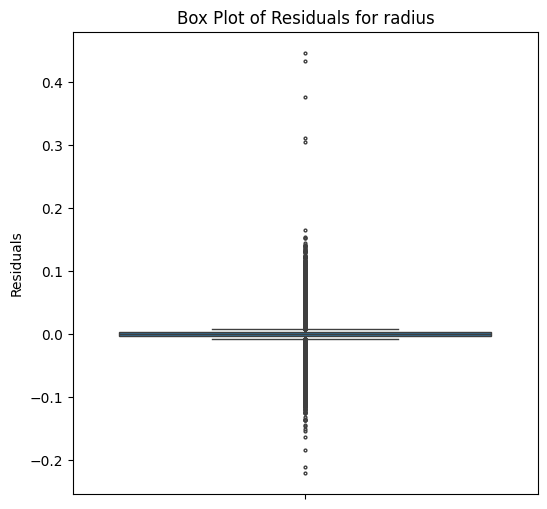

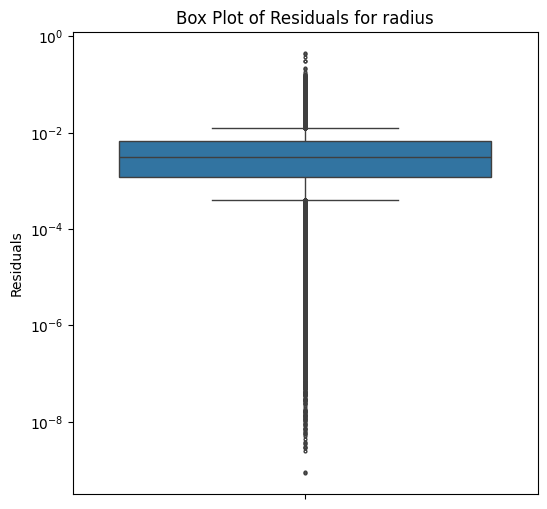

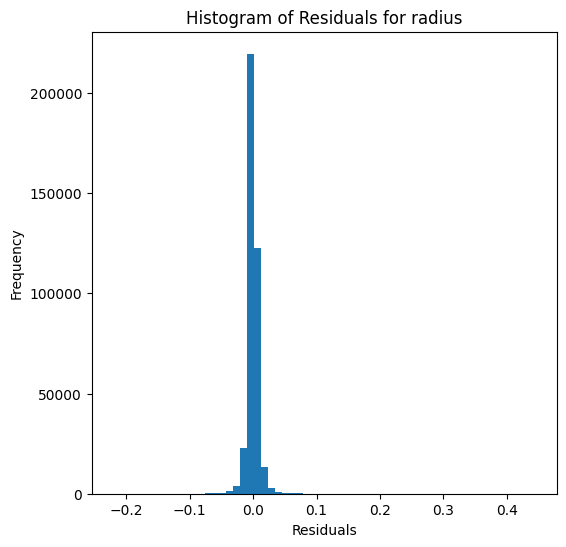

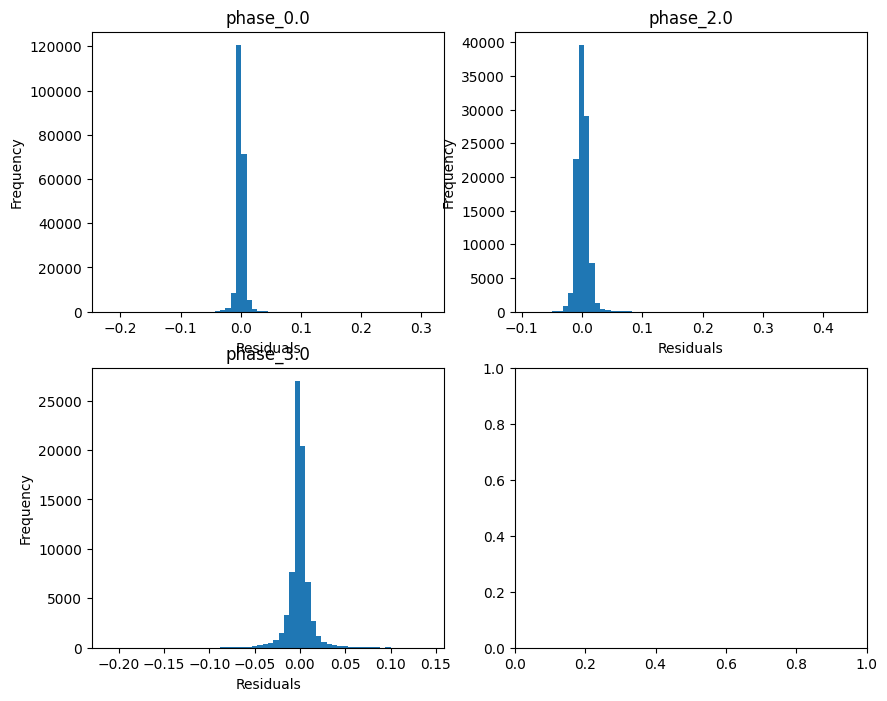

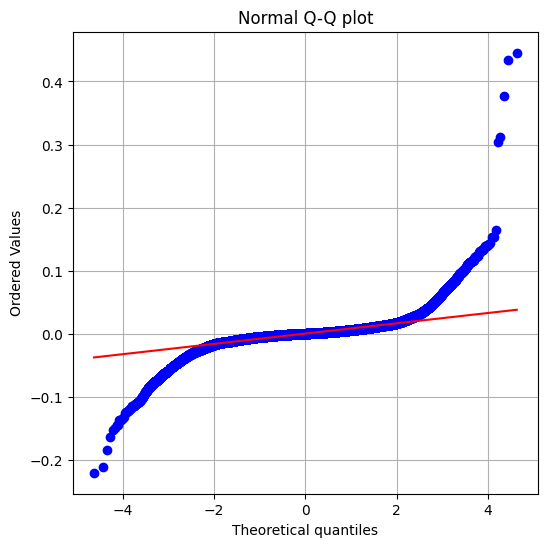

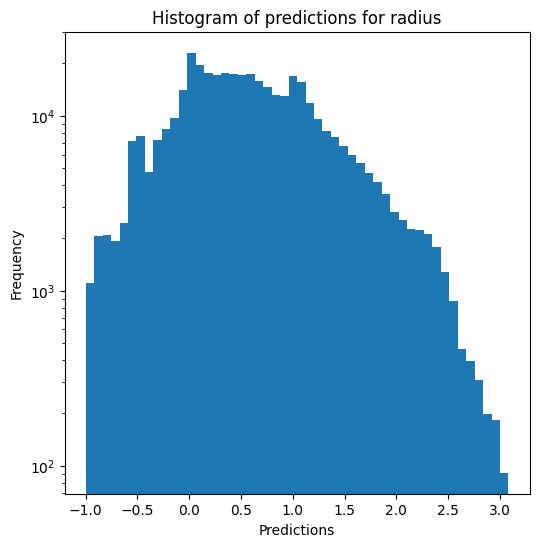

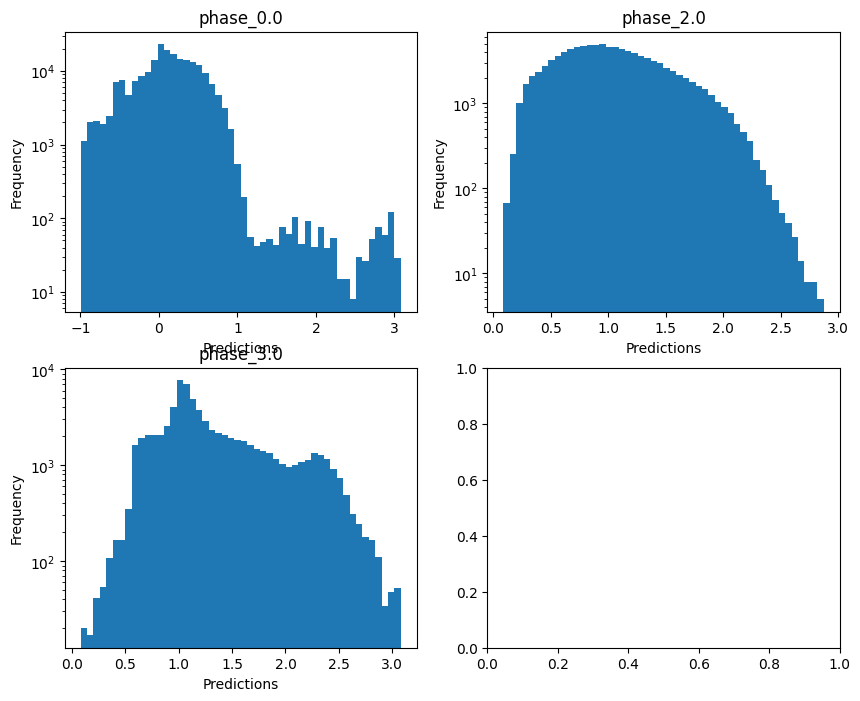

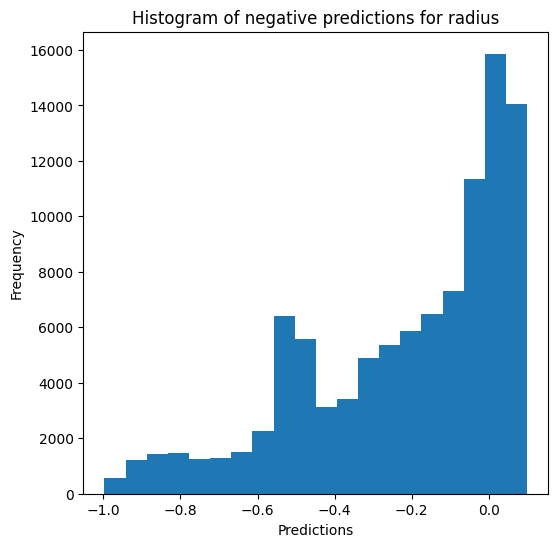

Saving predictions and results...


In [19]:
best_params_DT = {'criterion': 'squared_error', 'splitter': "best", 'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': None, 'max_leaf_nodes': None}

print(path_to_results)
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, **best_params_DT)

### Random forest

#### Test optuna (pas utilisé au final)

In [ ]:
def RF_objective(trial, X_train, y_train, X_test, y_test):
    # Hyperparameters which will be tuned
    criterion = trial.suggest_categorical("criterion", ["squared_error", "friedman_mse", "absolute_error"])
    # n_estimators = trial.suggest_int("n_estimators", 75, 125)
    max_depth = trial.suggest_int("max_depth", 3, 50)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)

    mdl = RandomForestRegressor(
        criterion = criterion,
        max_depth = max_depth,
        min_samples_split = min_samples_split,
        min_samples_leaf = min_samples_leaf,
        n_jobs = 10
    )
    mdl.fit(X_train, y_train)
    preds = mdl.predict(X_test)
    # truth, preds = Model_trainer.Kfold_pipeline(RandomForestRegressor, X_train_data=X_train, y_train_data=y_train, n_splits=10, 
    #                                             criterion = criterion,
    #                                             # n_estimators = n_estimators,
    #                                             max_depth = max_depth,
    #                                             min_samples_split = min_samples_split,
    #                                             min_samples_leaf = min_samples_leaf,
    #                                             n_jobs = 10
    #                                             )
    metrics_dict = dict()
    for i, output_param in enumerate(output_parameters):
        metrics_dict[output_param] = dict()
        metrics_dict[output_param]["RMSE"] = root_mean_squared_error(y_test[:, i], preds[:, i])
        metrics_dict[output_param]["MAE"] = mean_absolute_error(y_test[:, i], preds[:, i])
        metrics_dict[output_param]["MAX_ER"] = max_error(y_test[:, i], preds[:, i])

    return metrics_dict["mass"]["RMSE"], metrics_dict["mass"]["MAE"], metrics_dict["mass"]["MAX_ER"]

In [ ]:
study_RF = optuna.create_study(directions=["minimize", "minimize", "minimize"]) # we want to minimize the RMSE, MAE and MAX_ER
study_RF.optimize(lambda trial: RF_objective(trial, X_train, y_train, X_test, y_test, output_parameters), n_trials=100)

In [ ]:
for trial in study_RF.best_trials:
    print(f"[RMSE, MAE, MAX_ER] : {trial.values} \n parameters : {trial.params}")

In [ ]:

best_params_RF = 

rf_evaluator = Model_evaluator("radnom_forest", path=path_to_results, physical_model=physical_model, output_parameters=["mass", "radius"])
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, path_to_predictions, tag, random_state=12, override=True, use_preds=False, **best_params_RF, n_jobs=10)

#### Tuning the n_estimators and criterion parameters

In [27]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'criterion' : ["squared_error", "friedman_mse"], # absolute_error prend beaucoup de temps et poisson n'est pas possible avec des valeurs négatives
             'n_estimators' : [50, 100, 200, 400, 600]
            }

gscv_rf = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 10 candidates, totalling 100 fits
[CV] END ...........criterion=squared_error, n_estimators=50; total time=  24.2s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=  27.6s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=  27.4s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=  32.4s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=  27.9s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=  27.9s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=  29.2s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=  27.4s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=  27.0s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=  25.2s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=  52.6s
[CV] END ..........criterion=squared_error, n_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_n_estimators,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,27.363617,2.091493,0.352337,0.083732,squared_error,50,"{'criterion': 'squared_error', 'n_estimators':...",-0.018292,-0.019157,-0.019175,-0.018555,-0.019997,-0.018688,-0.019541,-0.018392,-0.019258,-0.018580,-0.018963,0.000523,5,-0.007113,-0.007149,-0.007172,-0.006942,-0.007292,-0.007075,-0.007049,-0.007075,-0.007053,-0.007144,-0.007106,0.000088,5
1,47.544359,10.979403,0.603447,0.177715,squared_error,100,"{'criterion': 'squared_error', 'n_estimators':...",-0.018016,-0.018736,-0.019183,-0.018077,-0.019752,-0.018360,-0.019244,-0.018506,-0.018814,-0.018560,-0.018725,0.000517,4,-0.006931,-0.007021,-0.007023,-0.006803,-0.007090,-0.006909,-0.006855,-0.006983,-0.006872,-0.007015,-0.006950,0.000086,4
2,29.584873,2.604739,0.492351,0.015358,squared_error,200,"{'criterion': 'squared_error', 'n_estimators':...",-0.018102,-0.018467,-0.018740,-0.018034,-0.019376,-0.018191,-0.018998,-0.018298,-0.018697,-0.018279,-0.018518,0.000409,3,-0.006913,-0.006886,-0.006917,-0.006722,-0.007021,-0.006836,-0.006799,-0.006876,-0.006778,-0.006901,-0.006865,0.000080,3
3,60.104205,0.950653,24.184884,1.708750,squared_error,400,"{'criterion': 'squared_error', 'n_estimators':...",-0.017964,-0.018430,-0.018760,-0.017979,-0.019249,-0.018122,-0.018970,-0.018169,-0.018677,-0.018324,-0.018464,0.000414,2,-0.006858,-0.006839,-0.006883,-0.006665,-0.006948,-0.006774,-0.006751,-0.006830,-0.006741,-0.006878,-0.006817,0.000079,2
4,94.136396,7.079699,50.312455,8.270974,squared_error,600,"{'criterion': 'squared_error', 'n_estimators':...",-0.017926,-0.018293,-0.018733,-0.017936,-0.019346,-0.018136,-0.018883,-0.018114,-0.018558,-0.018230,-0.018416,0.000435,1,-0.006836,-0.006818,-0.006879,-0.006647,-0.006952,-0.006756,-0.006722,-0.006805,-0.006734,-0.006854,-0.006800,0.000083,1
5,7.972757,0.289957,0.154178,0.017605,friedman_mse,50,"{'criterion': 'friedman_mse', 'n_estimators': 50}",-0.019426,-0.019487,-0.020001,-0.018819,-0.021526,-0.019965,-0.020438,-0.020070,-0.020128,-0.020225,-0.020009,0.000677,10,-0.007660,-0.007635,-0.007663,-0.007381,-0.007750,-0.007577,-0.007569,-0.007687,-0.007571,-0.007629,-0.007612,0.000094,10
6,15.040163,0.463688,0.264305,0.006028,friedman_mse,100,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.019061,-0.019215,-0.019553,-0.018724,-0.020905,-0.019911,-0.019994,-0.019579,-0.019814,-0.020338,-0.019709,0.000603,9,-0.007477,-0.007444,-0.007498,-0.007225,-0.007509,-0.007434,-0.007376,-0.007482,-0.007384,-0.007485,-0.007431,0.000081,9
7,28.930539,0.691346,0.513724,0.018067,friedman_mse,200,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.018923,-0.018971,-0.019666,-0.018607,-0.020858,-0.019388,-0.020044,-0.019542,-0.019794,-0.019768,-0.019556,0.000610,8,-0.007389,-0.007325,-0.007443,-0.007160,-0.007443,-0.007314,-0.007305,-0.007393,-0.007345,-0.007350,-0.007347,0.000078,8
8,59.273288,1.269556,22.776191,1.194059,friedman_mse,400,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.018925

Best parameters {'criterion': 'squared_error', 'n_estimators': 600}
Best score -0.01841555027497129


#### Tuning the n_estimators parameter further

In [10]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'n_estimators' : [100, 1000]
            }

gscv_rf = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 2 candidates, totalling 20 fits
[CV] END ...................................n_estimators=100; total time=  16.1s
[CV] END ...................................n_estimators=100; total time=  15.9s
[CV] END ...................................n_estimators=100; total time=  15.6s
[CV] END ...................................n_estimators=100; total time=  15.5s
[CV] END ...................................n_estimators=100; total time=  15.4s
[CV] END ...................................n_estimators=100; total time=  15.5s
[CV] END ...................................n_estimators=100; total time=  15.4s
[CV] END ...................................n_estimators=100; total time=  15.4s
[CV] END ...................................n_estimators=100; total time=  15.4s
[CV] END ...................................n_estimators=100; total time=  15.6s
[CV] END ..................................n_estimators=1000; total time= 3.7min
[CV] END ..................................n_est

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,15.413757,0.224142,0.260015,0.025585,100,{'n_estimators': 100},-0.018124,-0.018388,-0.018987,-0.018112,-0.019537,-0.018479,-0.018965,-0.018299,-0.018838,-0.018357,-0.018609,0.000435,2,-0.006973,-0.006932,-0.007010,-0.006761,-0.007123,-0.006883,-0.006840,-0.006909,-0.006876,-0.006987,-0.006929,0.000095,2
1,166.531170,26.808580,97.407573,8.695572,1000,{'n_estimators': 1000},-0.017897,-0.018315,-0.018702,-0.017952,-0.019303,-0.018122,-0.018849,-0.018173,-0.018614,-0.018211,-0.018414,0.000422,1,-0.006818,-0.006821,-0.006856,-0.006647,-0.006933,-0.006751,-0.006709,-0.006810,-0.006729,-0.006831,-0.006791,0.000078,1


Best parameters {'n_estimators': 1000}
Best score -0.018413790633118023


More estimators always gives better results, but the more you add, the less return there is

#### Tuning the max_depth, min_samples_split and min_samples_leaf parameters

In [10]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'max_depth' : [50, 100, None],
             'min_samples_split' : [2, 6, 10],
             'min_samples_leaf' : [1, 3, 5],
            }

gscv_rf = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             criterion="squared_error",
                                             n_estimators=100, # results with 600 are better but take more time, doing gridsearchcv with 100 is comparable to 600
                                            ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 27 candidates, totalling 270 fits
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  39.9s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  25.7s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  15.3s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  15.4s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  15.3s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  16.5s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  20.0s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  15.3s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  14.5s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  15.1s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=6; total time=  13.2s
[CV] END max_depth=50, m

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,19.066239,7.494079,0.346672,0.189577,50,1,2,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.018070,-0.018405,-0.018932,-0.018214,-0.019408,-0.018324,-0.019405,-0.018367,-0.018751,-0.018475,-0.018635,0.000451,3,-0.006963,-0.006981,-0.007010,-0.006801,-0.007072,-0.006899,-0.006907,-0.006979,-0.006889,-0.006999,-0.006950,0.000073,2
1,13.234663,0.254949,0.178984,0.011563,50,1,6,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.020293,-0.020437,-0.020874,-0.019948,-0.021409,-0.019995,-0.020932,-0.020185,-0.020579,-0.020418,-0.020507,0.000433,4,-0.008268,-0.008223,-0.008288,-0.008044,-0.008383,-0.008102,-0.008114,-0.008222,-0.008145,-0.008251,-0.008204,0.000097,5
2,12.615717,0.209923,0.141587,0.009882,50,1,10,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.023449,-0.022743,-0.023761,-0.022586,-0.024631,-0.023017,-0.023494,-0.023168,-0.023451,-0.023472,-0.023377,0.000544,13,-0.010062,-0.009939,-0.010072,-0.009742,-0.010141,-0.009856,-0.009851,-0.010047,-0.009962,-0.010063,-0.009974,0.000120,13
3,12.723128,0.189802,0.166532,0.005260,50,3,2,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.021474,-0.021107,-0.023427,-0.021505,-0.022921,-0.021331,-0.021699,-0.021641,-0.022028,-0.022094,-0.021923,0.000694,10,-0.008832,-0.008780,-0.008909,-0.008589,-0.008927,-0.008681,-0.008604,-0.008854,-0.008665,-0.008822,-0.008766,0.000117,11
4,12.577133,0.410892,0.173027,0.021800,50,3,6,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.021452,-0.021192,-0.023255,-0.021316,-0.022944,-0.021350,-0.021915,-0.021687,-0.022011,-0.021858,-0.021898,0.000658,7,-0.008810,-0.008704,-0.008894,-0.008600,-0.008901,-0.008708,-0.008648,-0.008834,-0.008716,-0.008817,-0.008763,0.000097,8
5,12.250243,0.057944,0.139791,0.011699,50,3,10,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.024032,-0.023357,-0.025871,-0.023682,-0.025420,-0.023704,-0.024086,-0.024099,-0.024461,-0.024535,-0.024325,0.000747,17,-0.010332,-0.010242,-0.010374,-0.010050,-0.010442,-0.010142,-0.010129,-0.010382,-0.010186,-0.010349,-0.010263,0.000124,16
6,12.080350,0.183569,0.134870,0.007410,50,5,2,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.025847,-0.025321,-0.027003,-0.024944,-0.026329,-0.025259,-0.025993,-0.025564,-0.026121,-0.026088,-0.025847,0.000569,24,-0.011116,-0.010937,-0.011059,-0.010719,-0.011105,-0.010855,-0.010872,-0.011011,-0.010976,-0.011035,-0.010969,0.000119,25
7,12.051122,0.120106,0.136412,0.011624,50,5,6,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.025800,-0.025453,-0.027131,-0.025076,-0.026247,-0.024941,-0.025843,-0.025708,-0.025671,-0.025885,-0.025775,0.000582,19,-0.011041,-0.011014,-0.011106,-0.010753,-0.011034,-0.010764,-0.010814,-0.011066,-0.010867,-0.010997,-0.010945,0.000126,19
8,12.011508,0.209440,0.132598,0.008916,50,5,10,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.025693,-0.025382,-0.027128,-0.024992,-0.026367,-0.025016,-0.025

Best parameters {'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best score -0.01861234974173217


#### Tuning the max_features and max_leaf_nodes parameters

In [ ]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {"max_features" : ["sqrt", "log2", None], 
             "max_leaf_nodes" : [50, 100, 200, None]
            }

gscv_rf = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             criterion="squared_error",
                                             n_estimators=100,
                                             max_depth=100,
                                             min_samples_leaf=1,
                                             min_samples_split=2
                                            ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 12 candidates, totalling 120 fits
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.3s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.3s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   3.9s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   3.9s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   3.8s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   3.9s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   3.8s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   3.8s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   3.8s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.0s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   4.3s
[CV] END ..............max_features=sqrt, max_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_max_leaf_nodes,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,4.001858,0.193971,0.041323,0.009564,sqrt,50,"{'max_features': 'sqrt', 'max_leaf_nodes': 50}",-0.240031,-0.240010,-0.240734,-0.246508,-0.248984,-0.234722,-0.239896,-0.246971,-0.247427,-0.241299,-0.242658,0.004316,9,-0.157862,-0.159053,-0.157954,-0.164212,-0.163593,-0.155786,-0.160517,-0.163153,-0.164011,-0.160025,-0.160616,0.002838,9
1,4.350417,0.060376,0.048240,0.009540,sqrt,100,"{'max_features': 'sqrt', 'max_leaf_nodes': 100}",-0.176822,-0.171333,-0.176986,-0.175245,-0.173457,-0.169563,-0.172682,-0.176540,-0.173750,-0.171524,-0.173790,0.002438,6,-0.115869,-0.113158,-0.115915,-0.114060,-0.113400,-0.112121,-0.114672,-0.117131,-0.115170,-0.112889,-0.114438,0.001507,6
2,4.791691,0.085841,0.045830,0.007512,sqrt,200,"{'max_features': 'sqrt', 'max_leaf_nodes': 200}",-0.126331,-0.124668,-0.124060,-0.124239,-0.125292,-0.122420,-0.123697,-0.125006,-0.123773,-0.127197,-0.124668,0.001305,5,-0.082767,-0.083265,-0.080241,-0.081277,-0.082654,-0.080876,-0.081086,-0.082462,-0.081934,-0.084367,-0.082093,0.001186,5
3,9.112118,0.266321,0.251955,0.010118,sqrt,None,"{'max_features': 'sqrt', 'max_leaf_nodes': None}",-0.018167,-0.018061,-0.019075,-0.018088,-0.018529,-0.017744,-0.018482,-0.018060,-0.018445,-0.018568,-0.018322,0.000355,2,-0.007048,-0.007021,-0.007108,-0.006908,-0.007147,-0.006904,-0.006919,-0.007068,-0.006982,-0.007059,-0.007016,0.000081,3
4,3.926251,0.053115,0.046285,0.012279,log2,50,"{'max_features': 'log2', 'max_leaf_nodes': 50}",-0.251939,-0.244202,-0.243227,-0.241331,-0.244238,-0.240558,-0.242354,-0.247292,-0.242573,-0.250272,-0.244799,0.003623,10,-0.166662,-0.160958,-0.159767,-0.159226,-0.162036,-0.160015,-0.160940,-0.163764,-0.159754,-0.166923,-0.162004,0.002701,10
5,4.332917,0.073399,0.051197,0.013906,log2,100,"{'max_features': 'log2', 'max_leaf_nodes': 100}",-0.175234,-0.175493,-0.174980,-0.175283,-0.172388,-0.174491,-0.171324,-0.174541,-0.173843,-0.173061,-0.174064,0.001323,7,-0.114795,-0.116623,-0.115064,-0.115211,-0.113367,-0.116853,-0.114277,-0.114690,-0.114153,-0.114425,-0.114946,0.001023,7
6,4.634098,0.068664,0.047368,0.006807,log2,200,"{'max_features': 'log2', 'max_leaf_nodes': 200}",-0.125255,-0.123117,-0.122778,-0.125657,-0.123832,-0.122625,-0.121583,-0.124659,-0.123478,-0.124765,-0.123775,0.001230,4,-0.081645,-0.081668,-0.080088,-0.082736,-0.081781,-0.080283,-0.080586,-0.082065,-0.081159,-0.081993,-0.081400,0.000809,4
7,8.857883,0.190839,0.240428,0.006964,log2,None,"{'max_features': 'log2', 'max_leaf_nodes': None}",-0.018237,-0.018184,-0.018889,-0.017833,-0.018397,-0.017580,-0.018553,-0.018293,-0.018267,-0.018396,-0.018263,0.000342,1,-0.007014,-0.007053,-0.007112,-0.006889,-0.007077,-0.006883,-0.006926,-0.007099,-0.006990,-0.007027,-0.007007,0.000079,2
8,6.524157,0.078312,0.042627,0.010981,None,50,"{'max_features': None, 'max_leaf_nodes': 50}",-0.342995,-0.336492,-0.338872,-0.332413,-0.339544,-0.334905,-0.336290,-0.339126,-0.336473,-0.336696,-0.337381,0.0

Best parameters {'max_features': 'log2', 'max_leaf_nodes': None}
Best score -0.018262833937952434


#### Training the model with all the fine-tuned parameters and checking the results

../../../../../../results/model_A_partial/fine_tuned_models/

mass_smaller_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9999425378250663
  RMSE :  0.024980941801751307
  MAE :  0.0070754963130687685
  MedAE :  0.0019800196713559703
  CORR :  0.9999714227438252
  MAX_ER :  1.8523984483083993
  Percentiles : 
    75th percentile :  0.006107793513370652
    90th percentile :  0.015638590279060074
    95th percentile :  0.026683472475316848
    99th percentile :  0.0748693555419031

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9999653089896505
  RMSE :  0.019319700834220608
  MAE :  0.009476020114997642
  MedAE :  0.004632786588913973
  CORR :  0.9999827956759852
  MAX_ER :  0.4634173297598494
  Percentiles : 
    75th percen

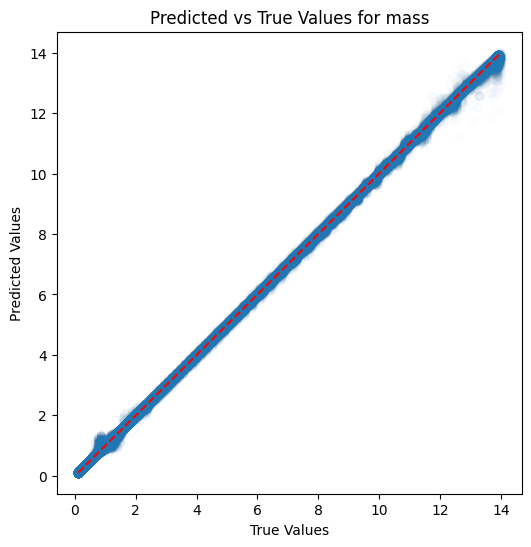

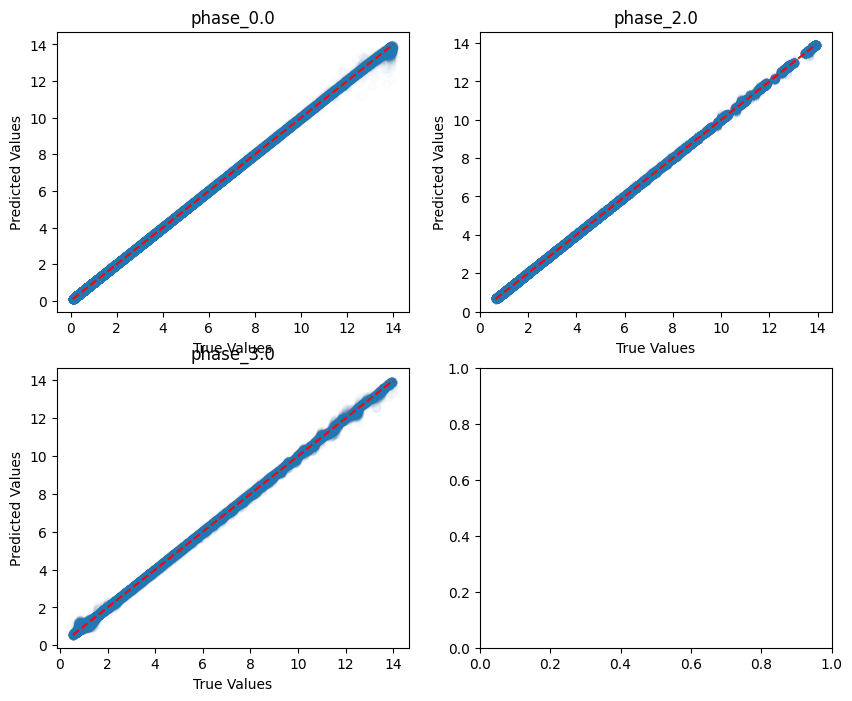

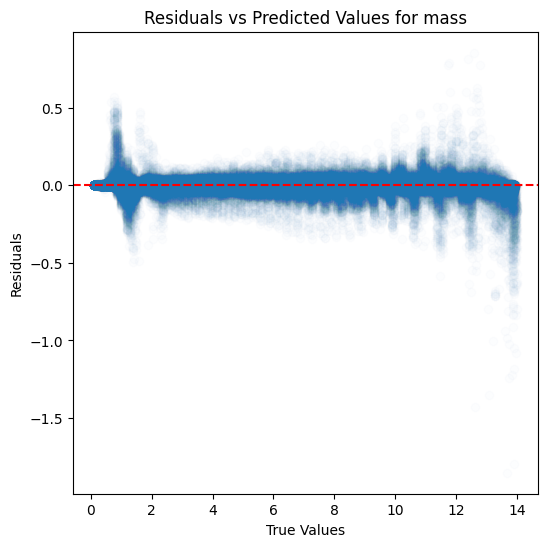

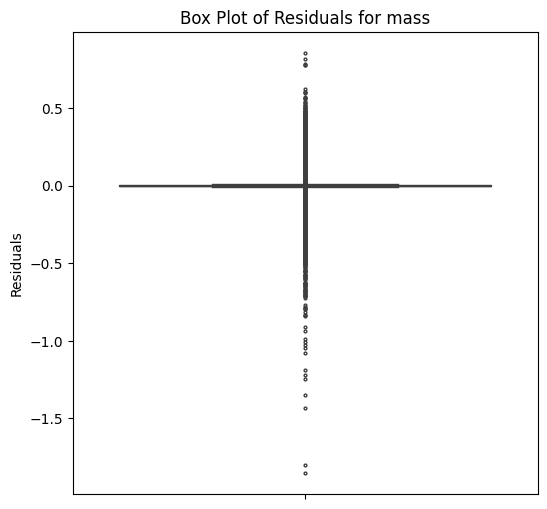

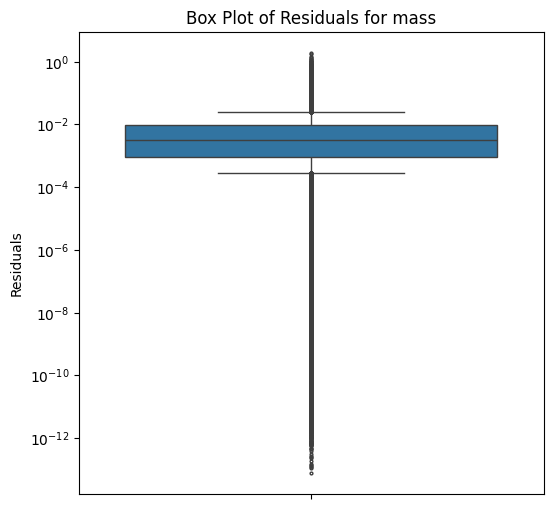

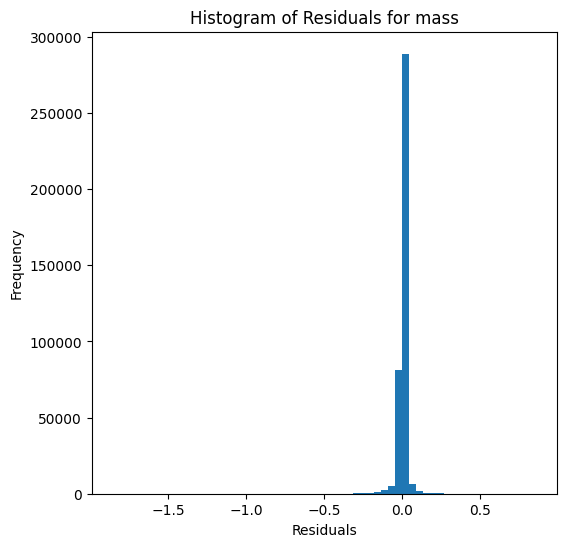

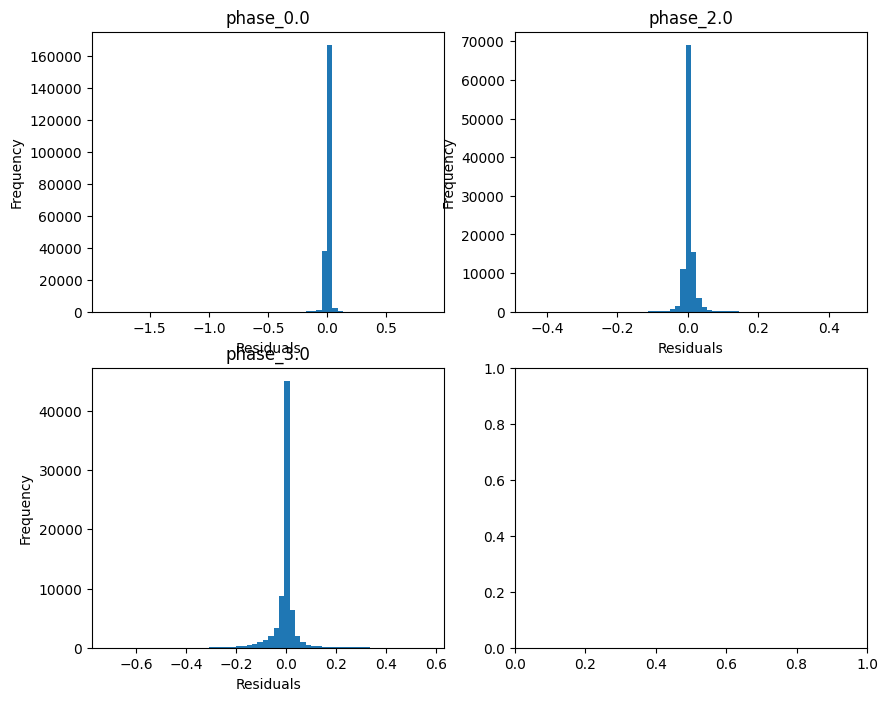

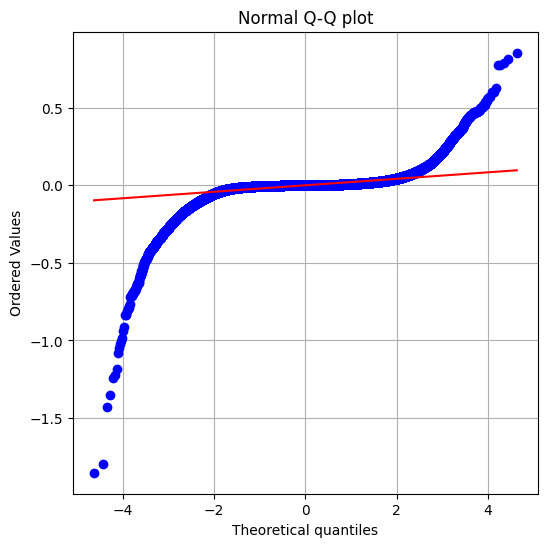

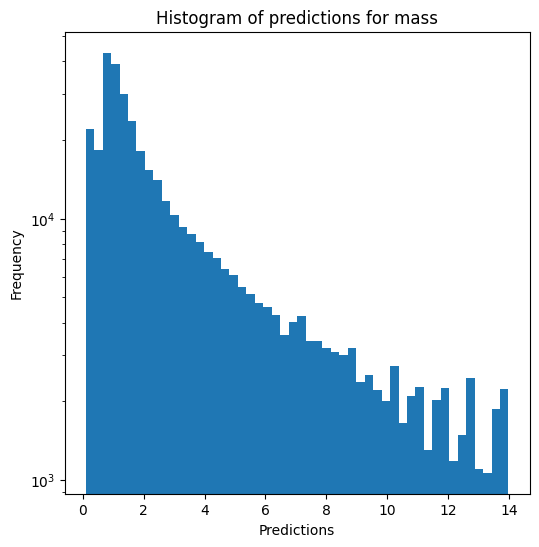

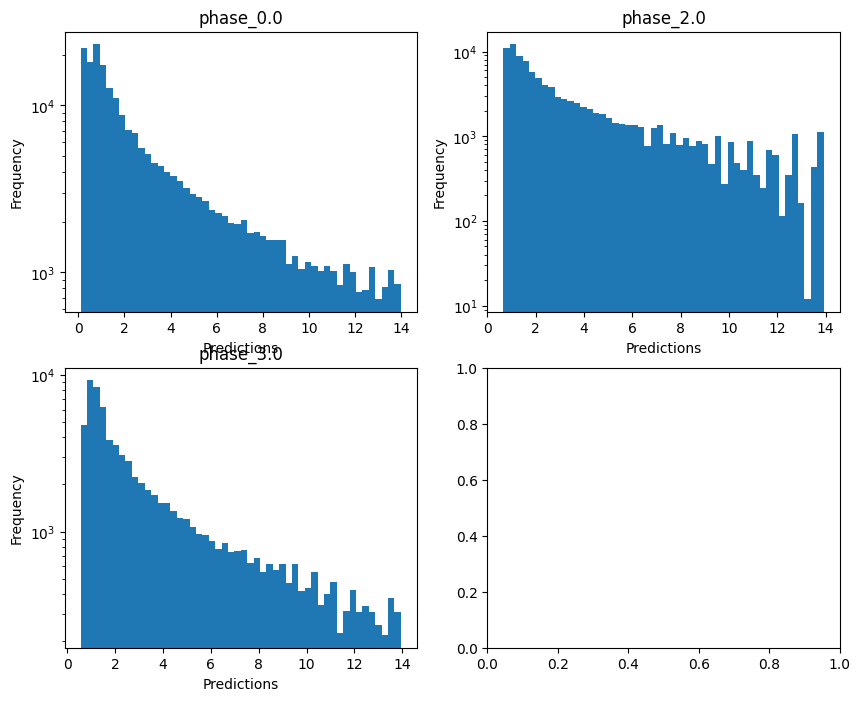


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9999840780371011
  RMSE :  0.0016813973503507214
  MAE :  0.0009642872118915092
  MedAE :  0.000521962433934875
  CORR :  0.9999920524670527
  MAX_ER :  0.045015022882480604
  Percentiles : 
    75th percentile :  0.0011494413041200913
    90th percentile :  0.002314170853051734
    95th percentile :  0.0034199357541379568
    99th percentile :  0.006357314650726092

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9999515863582138
  RMSE :  0.0034416141662153787
  MAE :  0.002401277977441483
  MedAE :  0.00166635459872011
  CORR :  0.9999781406360827
  MAX_ER :  0.04601574388528329
  Percentiles : 
    75th percentile :  0.003178931485693648
    90th percentile :  0.005475419394791838
    95th percentile :  0.007362658994930854
    99th percentile :  0.011687547893979872

radius resul

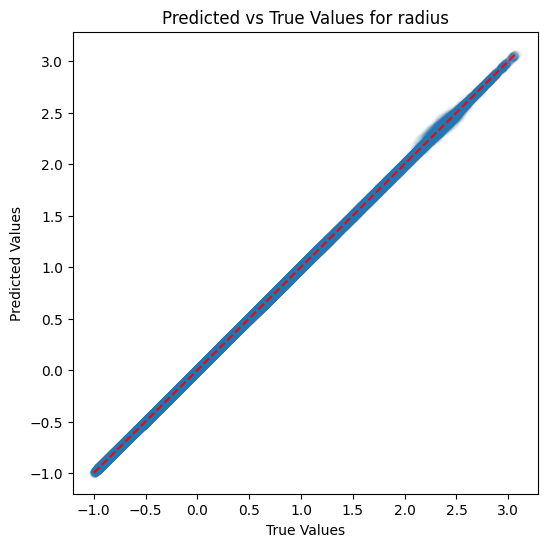

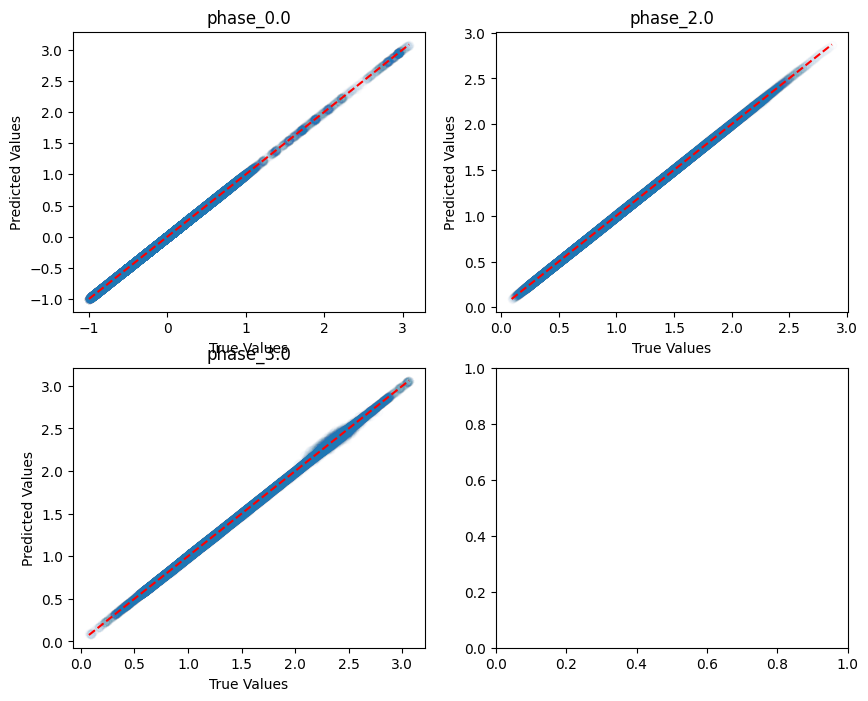

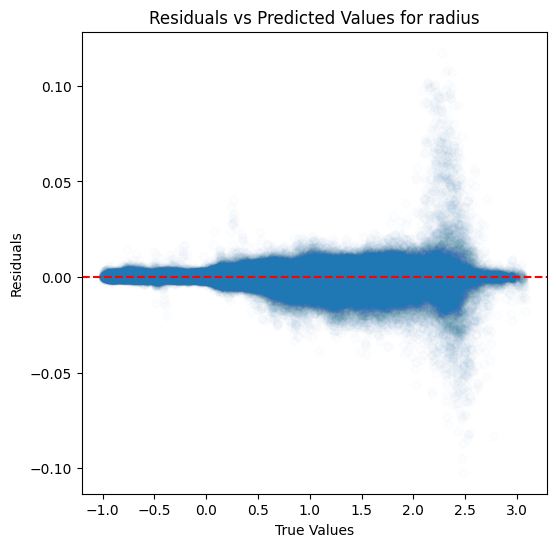

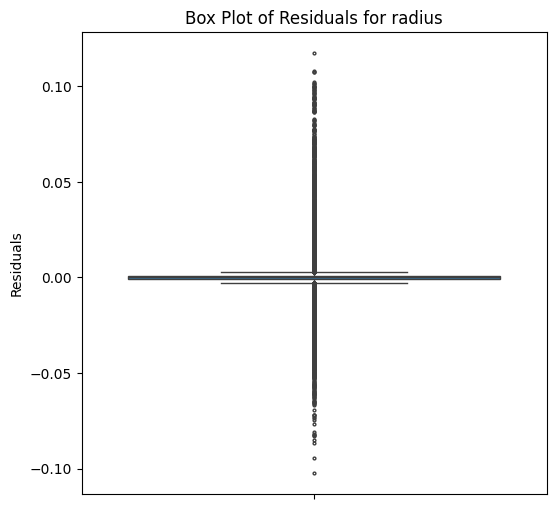

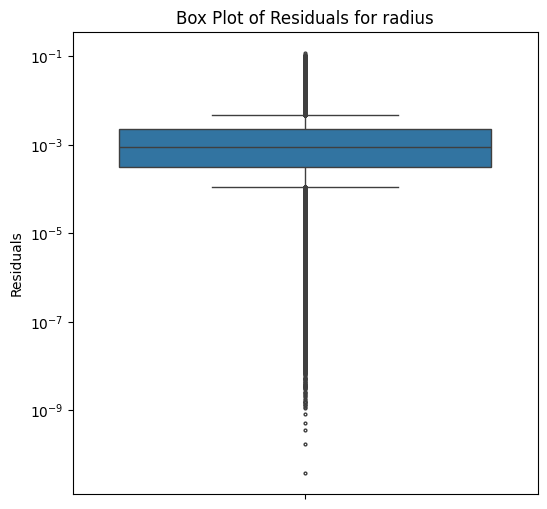

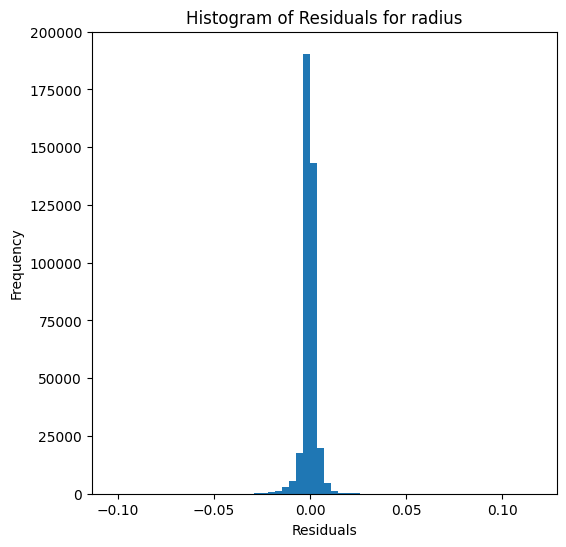

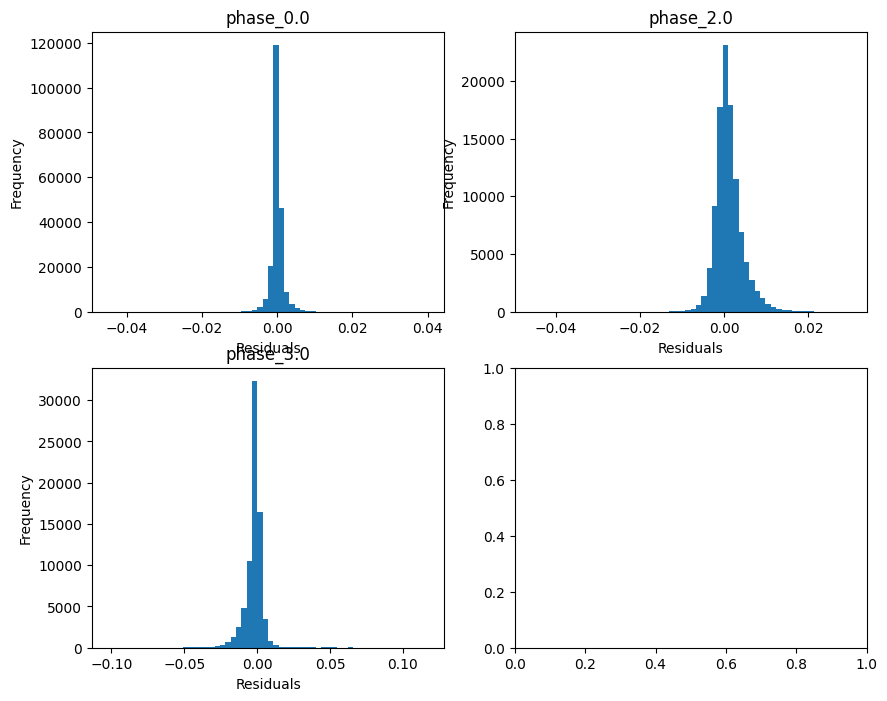

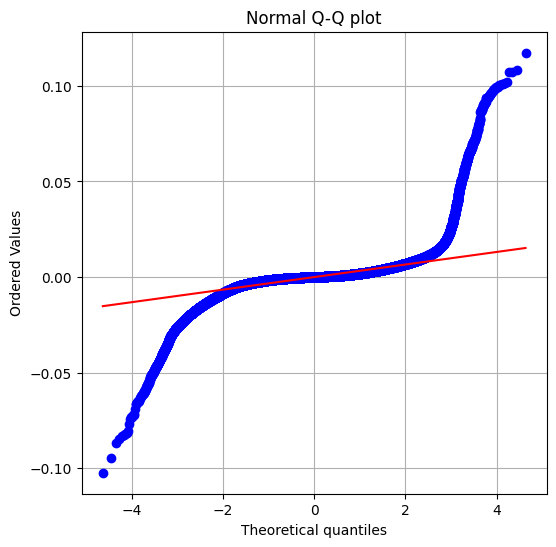

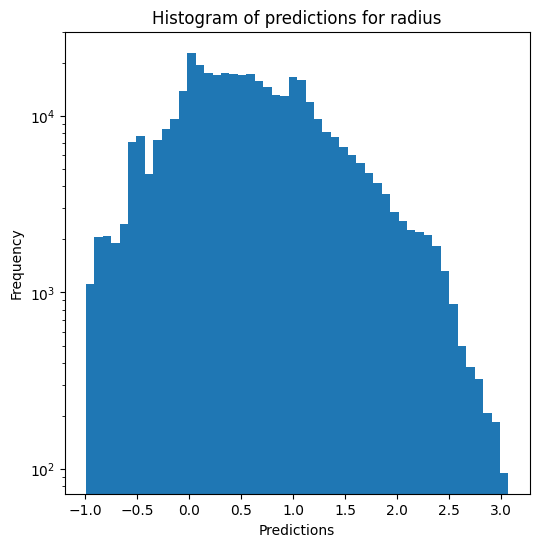

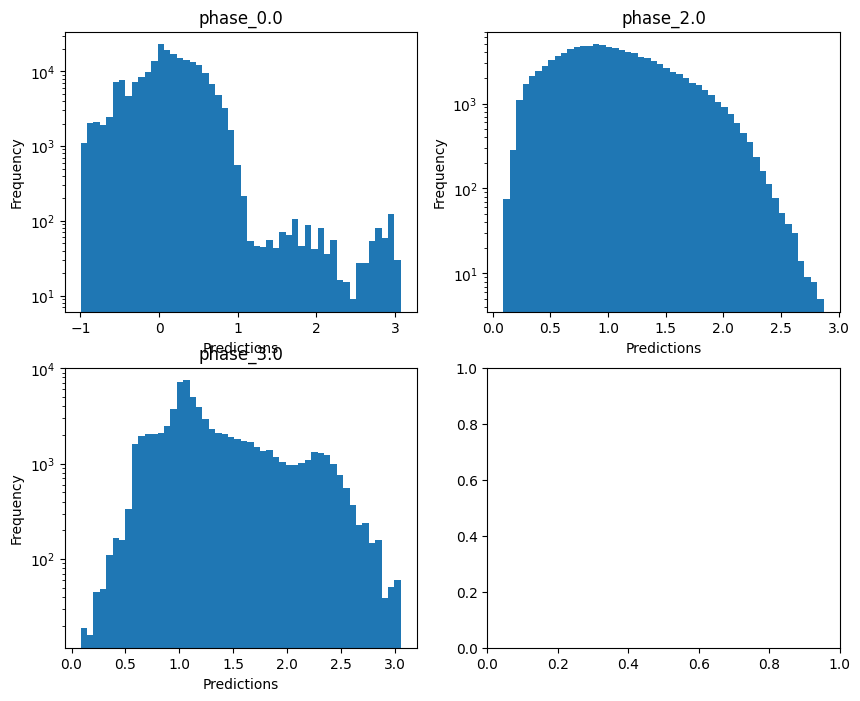

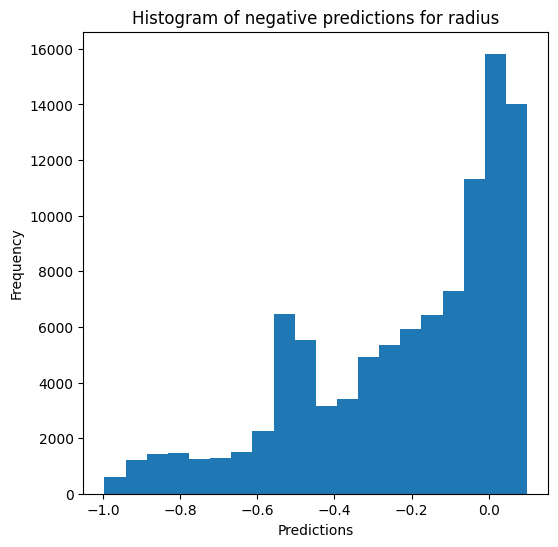

Saving predictions and results...


In [9]:
best_params_RF = {'n_jobs':10, 'n_estimators': 1000, 'criterion': 'squared_error', 'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': 'log2', 'max_leaf_nodes': None}

print(path_to_results)
dt_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
dt_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, **best_params_RF)

### K nearest neighbours

#### Testing the uniform weights with brute strength

In [10]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'n_neighbors' : [5, 10, 20, 30, 50],
             'weights' : ["uniform"],
             'algorithm' : ["brute"]
            }

gscv_rf = GridSearchCV(KNeighborsRegressor(n_jobs = 5,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 5 candidates, totalling 50 fits
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   6.1s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.0s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.0s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.9s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.0s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.0s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.0s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.6s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.6s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.5s
[CV] END ...algorithm=brute, n_neighbors=10, weights=uniform; total time=   4.7s
[CV] END ...algorithm=brute, n_neighbors=10, wei

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_n_neighbors,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.016356,0.017806,4.446121,0.620717,brute,5,uniform,"{'algorithm': 'brute', 'n_neighbors': 5, 'weig...",-0.046392,-0.043623,-0.043979,-0.044503,-0.045509,-0.044025,-0.045140,-0.046301,-0.043207,-0.045526,-0.044820,0.001059,1,-0.016832,-0.016411,-0.016285,-0.016103,-0.016688,-0.016119,-0.016329,-0.016948,-0.016117,-0.016532,-0.016436,0.000290,1
1,0.011086,0.001765,4.665032,0.065477,brute,10,uniform,"{'algorithm': 'brute', 'n_neighbors': 10, 'wei...",-0.057854,-0.054112,-0.055972,-0.056516,-0.056772,-0.056324,-0.055585,-0.059050,-0.056439,-0.055350,-0.056397,0.001284,2,-0.021062,-0.020440,-0.020635,-0.020663,-0.020862,-0.020568,-0.020758,-0.021256,-0.020793,-0.020489,-0.020753,0.000242,2
2,0.011269,0.001228,4.625027,0.096331,brute,20,uniform,"{'algorithm': 'brute', 'n_neighbors': 20, 'wei...",-0.063042,-0.059660,-0.061674,-0.062206,-0.061896,-0.061395,-0.059699,-0.064684,-0.060815,-0.061336,-0.061641,0.001419,3,-0.023804,-0.023149,-0.023301,-0.023409,-0.023543,-0.023345,-0.023094,-0.024109,-0.023411,-0.023207,-0.023437,0.000296,3
3,0.011199,0.001402,4.638166,0.081491,brute,30,uniform,"{'algorithm': 'brute', 'n_neighbors': 30, 'wei...",-0.079888,-0.076045,-0.077265,-0.079637,-0.078571,-0.076906,-0.075010,-0.081634,-0.077689,-0.078173,-0.078082,0.001853,4,-0.027844,-0.027206,-0.027232,-0.027358,-0.027740,-0.027192,-0.027074,-0.028313,-0.027674,-0.027409,-0.027504,0.000365,4
4,0.012113,0.001597,4.827608,0.083619,brute,50,uniform,"{'algorithm': 'brute', 'n_neighbors': 50, 'wei...",-0.110351,-0.106476,-0.108113,-0.110791,-0.110661,-0.107593,-0.105811,-0.113986,-0.109362,-0.109561,-0.109270,0.002273,5,-0.037270,-0.036415,-0.036613,-0.036653,-0.037488,-0.036447,-0.036341,-0.038213,-0.036972,-0.036841,-0.036925,0.000557,5


Best parameters {'algorithm': 'brute', 'n_neighbors': 5, 'weights': 'uniform'}
Best score -0.04482042845903464


#### Testing the uniform weights with algorithms

In [11]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'n_neighbors' : [5, 10, 20, 30, 50],
             'weights' : ["uniform"],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 30, 50, 75, 100]
            }

gscv_rf = GridSearchCV(KNeighborsRegressor(n_jobs = 5,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 50 candidates, totalling 500 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.1s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.1s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.1s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.294211,0.029450,0.830302,0.053064,ball_tree,15,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.046412,-0.043635,-0.043988,-0.044502,-0.045491,-0.044040,-0.045129,-0.046292,-0.043206,-0.045528,-0.044822,0.001056,2,-0.016838,-0.016413,-0.016290,-0.016102,-0.016679,-0.016132,-0.016322,-0.016942,-0.016119,-0.016535,-0.016437,0.000288,2
1,0.269560,0.010127,0.978404,0.065270,ball_tree,15,10,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.057851,-0.054113,-0.055967,-0.056520,-0.056767,-0.056320,-0.055586,-0.059051,-0.056436,-0.055350,-0.056396,0.001283,12,-0.021059,-0.020440,-0.020631,-0.020669,-0.020855,-0.020562,-0.020761,-0.021256,-0.020790,-0.020490,-0.020751,0.000242,12
2,0.266594,0.016729,1.097411,0.053069,ball_tree,15,20,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.063046,-0.059665,-0.061672,-0.062207,-0.061892,-0.061395,-0.059698,-0.064686,-0.060814,-0.061333,-0.061641,0.001420,26,-0.023807,-0.023154,-0.023300,-0.023409,-0.023542,-0.023345,-0.023094,-0.024108,-0.023410,-0.023209,-0.023438,0.000296,28
3,0.255784,0.021686,1.317458,0.066901,ball_tree,15,30,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.079888,-0.076045,-0.077265,-0.079639,-0.078571,-0.076906,-0.075011,-0.081634,-0.077689,-0.078173,-0.078082,0.001853,33,-0.027843,-0.027207,-0.027231,-0.027360,-0.027742,-0.027191,-0.027076,-0.028312,-0.027672,-0.027409,-0.027504,0.000364,36
4,0.251248,0.023550,1.598646,0.068637,ball_tree,15,50,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.110351,-0.106476,-0.108112,-0.110791,-0.110662,-0.107593,-0.105810,-0.113987,-0.109362,-0.109561,-0.109270,0.002273,44,-0.037270,-0.036415,-0.036612,-0.036654,-0.037489,-0.036447,-0.036340,-0.038215,-0.036972,-0.036840,-0.036925,0.000558,44
5,0.242892,0.012889,0.952887,0.071569,ball_tree,30,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.046412,-0.043635,-0.043988,-0.044502,-0.045504,-0.044040,-0.045129,-0.046292,-0.043206,-0.045528,-0.044824,0.001057,10,-0.016838,-0.016413,-0.016290,-0.016102,-0.016683,-0.016132,-0.016322,-0.016942,-0.016119,-0.016535,-0.016438,0.000288,10
6,0.242257,0.010953,1.112670,0.082493,ball_tree,30,10,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.057851,-0.054113,-0.055967,-0.056520,-0.056767,-0.056320,-0.055586,-0.059051,-0.056436,-0.055350,-0.056396,0.001283,11,-0.021059,-0.020440,-0.020630,-0.020669,-0.020855,-0.020562,-0.020761,-0.021256,-0.020790,-0.020490,-0.020751,0.000242,11
7,0.231001,0.009536,1.322961,0.041940,ball_tree,30,20,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.063047,-0.059664,-0.061672,-0.062207,-0.061892,-0.061395,-0.059698,-0.064686,-0.060814,-0.061333,-0.061641,0.001420,27,-0.023807,-0.023154,-0.023301,-0.023409,-0.023542,-0.023345,-0.023094,-0.024109,-0.023410,-0.023209,-0.023438,0.000296,25
8,0.246275,0.041084,1.566794,0.07961

Best parameters {'algorithm': 'kd_tree', 'leaf_size': 100, 'n_neighbors': 5, 'weights': 'uniform'}
Best score -0.044821305235632006


the algorithms give almost the same results then brute force with much less time. It is better to use them with distance calculation

#### Testing the distance weights with algorithms

In [9]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'n_neighbors' : [5, 25, 50],
             'weights' : ["distance"],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 50, 100],
             'p' : [1.0, 1.3, 1.6, 2.0]
            }

gscv_rf = GridSearchCV(KNeighborsRegressor(n_jobs = 5,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rf.fit(X_train, y_train)
display_grid_search(gscv_rf)

Fitting 10 folds for each of 72 candidates, totalling 720 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   0.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.1s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.1s
[CV] END a

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_p,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.292720,0.038366,0.802759,0.069877,ball_tree,15,5,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.032401,-0.030986,-0.031356,-0.031023,-0.032832,-0.031294,-0.032577,-0.033061,-0.031002,-0.031882,-0.031841,0.000772,1,-0.011927,-0.011747,-0.011682,-0.011509,-0.011862,-0.011500,-0.011687,-0.011965,-0.011582,-0.011720,-0.011718,0.000154,1
1,0.520174,0.035560,1.863795,0.112994,ball_tree,15,5,1.3,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.033121,-0.031736,-0.031893,-0.031985,-0.033377,-0.031725,-0.033646,-0.033521,-0.031249,-0.032998,-0.032525,0.000845,8,-0.012192,-0.011985,-0.011888,-0.011739,-0.012097,-0.011715,-0.011953,-0.012208,-0.011755,-0.011987,-0.011952,0.000171,8
2,0.499664,0.033038,2.007393,0.101218,ball_tree,15,5,1.6,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.034004,-0.032442,-0.032367,-0.032620,-0.033815,-0.032381,-0.034675,-0.034106,-0.031814,-0.034135,-0.033236,0.000953,13,-0.012430,-0.012209,-0.012050,-0.011951,-0.012318,-0.011943,-0.012190,-0.012423,-0.011975,-0.012207,-0.012170,0.000176,13
3,0.257338,0.012282,0.982467,0.094591,ball_tree,15,5,2.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.034715,-0.032975,-0.032979,-0.033318,-0.034371,-0.033018,-0.035354,-0.034633,-0.032164,-0.034451,-0.033798,0.000978,21,-0.012653,-0.012425,-0.012248,-0.012151,-0.012527,-0.012135,-0.012387,-0.012644,-0.012168,-0.012398,-0.012374,0.000185,21
4,0.247133,0.008591,1.358417,0.099940,ball_tree,15,25,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.047901,-0.045546,-0.046130,-0.047013,-0.047668,-0.046648,-0.045983,-0.048948,-0.045461,-0.046925,-0.046822,0.001056,29,-0.017097,-0.016625,-0.016671,-0.016675,-0.016941,-0.016615,-0.016548,-0.017214,-0.016709,-0.016688,-0.016778,0.000214,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,0.259211,0.016570,0.372480,0.045824,kd_tree,100,25,2.0,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.051667,-0.048676,-0.049564,-0.050364,-0.050578,-0.049900,-0.049416,-0.052447,-0.048744,-0.050222,-0.050158,0.001136,45,-0.018027,-0.017536,-0.017501,-0.017554,-0.017779,-0.017525,-0.017426,-0.018104,-0.017627,-0.017575,-0.017665,0.000219,45
68,0.247699,0.008401,0.660858,0.089309,kd_tree,100,50,1.0,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.063759,-0.060702,-0.062118,-0.063368,-0.063774,-0.062216,-0.060657,-0.065732,-0.061358,-0.062678,-0.062636,0.001497,50,-0.022303,-0.021756,-0.022003,-0.021980,-0.022373,-0.021831,-0.021732,-0.022804,-0.021919,-0.021970,-0.022067,0.000316,51
69,0.255315,0.018262,1.312367,0.050436,kd_tree,100,50,1.3,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.066956,-0.063880,-0.065267,-0.066684,-0.067005,-0.065442,-0.063781,-0.069124,-0.06473

Best parameters {'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 5, 'p': 1.0, 'weights': 'distance'}
Best score -0.03184134715056022


#### Training the model with all the fine-tuned parameters and checking the results

../../../../../../results/model_A_partial/fine_tuned_models/

mass_smaller_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9996375984674731
  RMSE :  0.06276485816567164
  MAE :  0.020810555955227256
  MedAE :  0.0055259148548665316
  CORR :  0.9998219337379322
  MAX_ER :  2.5615874219368404
  Percentiles : 
    75th percentile :  0.018095410663052647
    90th percentile :  0.047963367019583106
    95th percentile :  0.07860137550819492
    99th percentile :  0.2504000342122471

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9999062442143852
  RMSE :  0.03149743149485837
  MAE :  0.012403816410658327
  MedAE :  0.0029638125724237296
  CORR :  0.999953177740565
  MAX_ER :  0.6432729311521204
  Percentiles : 
    75th percentile

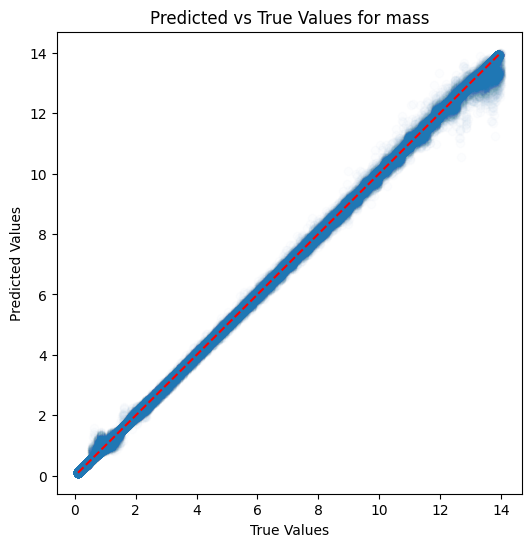

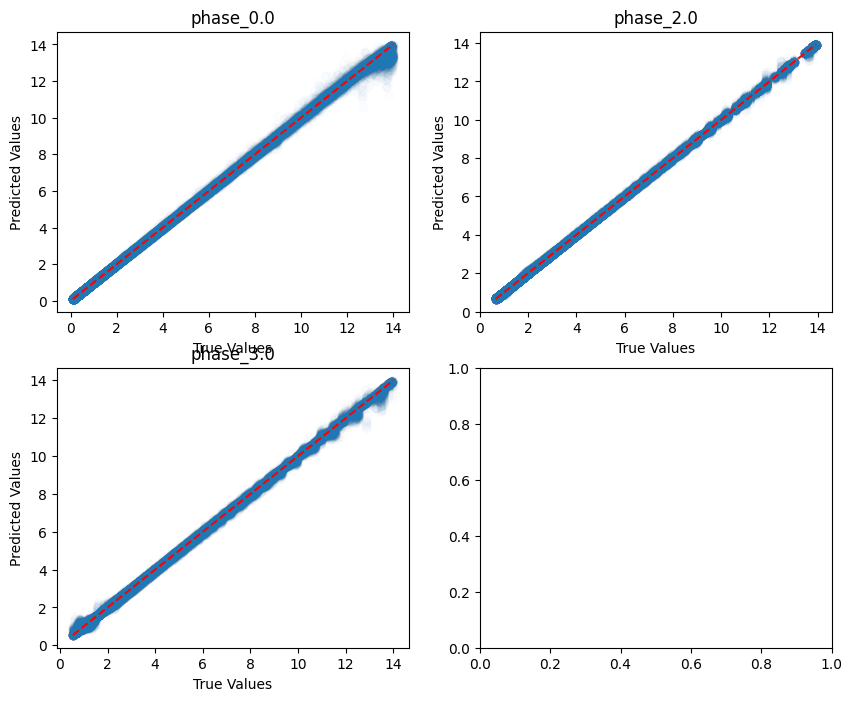

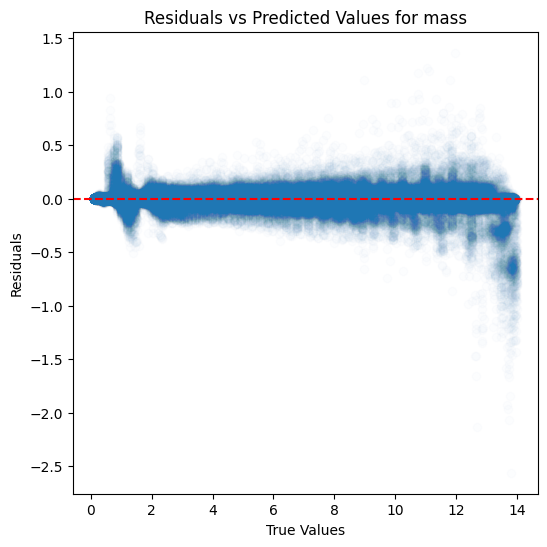

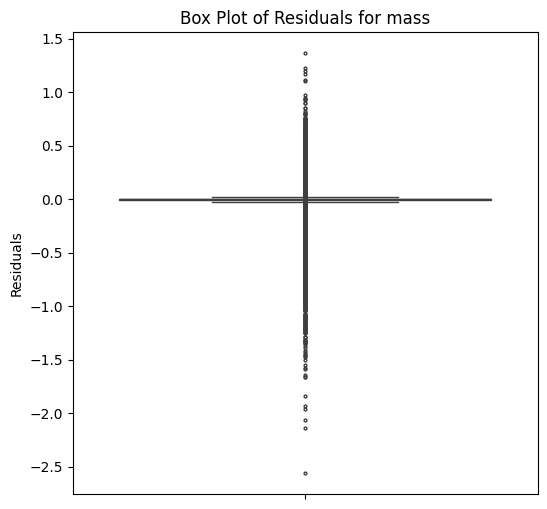

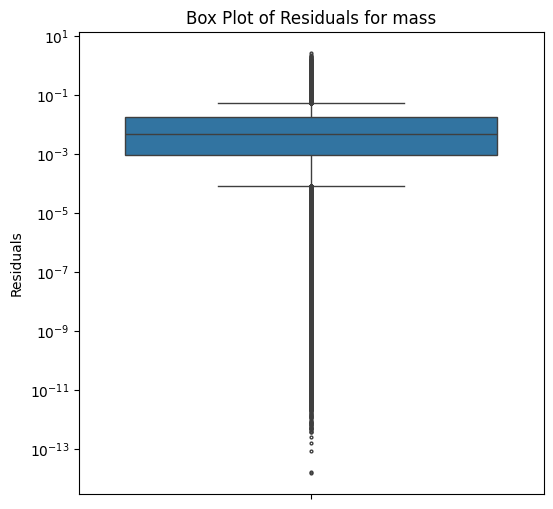

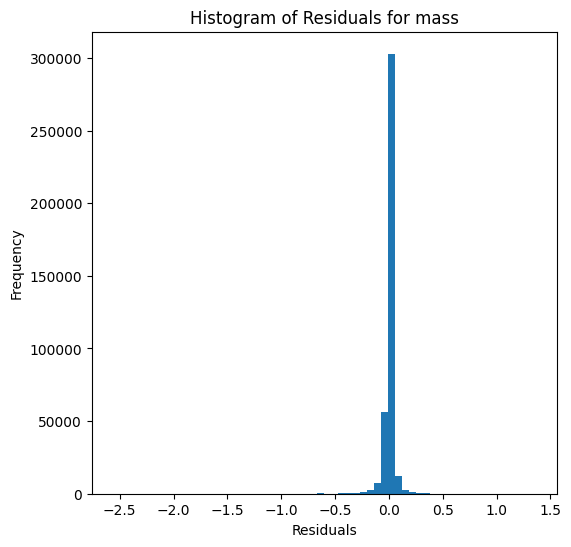

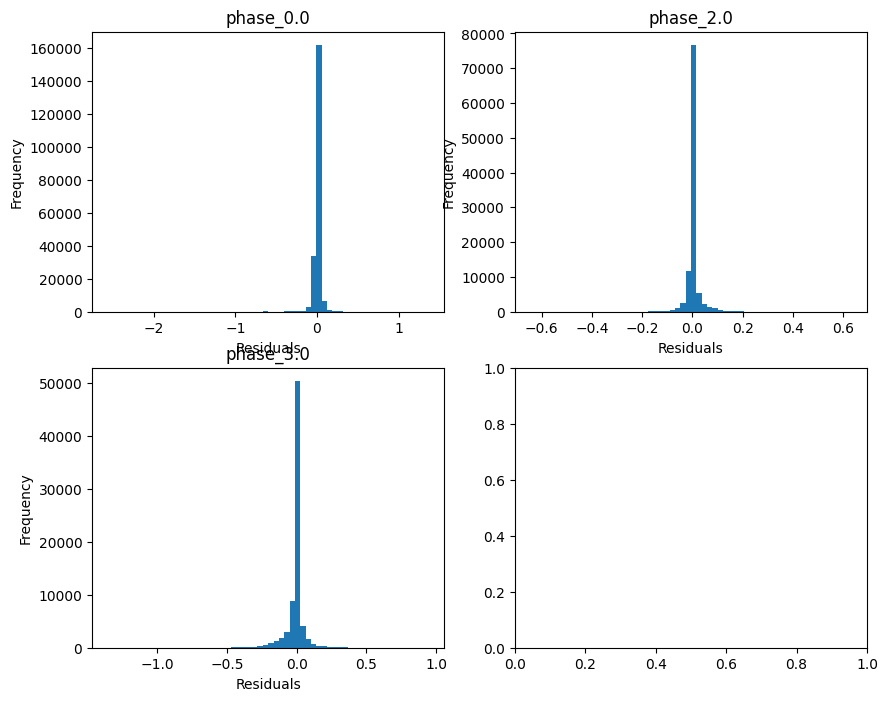

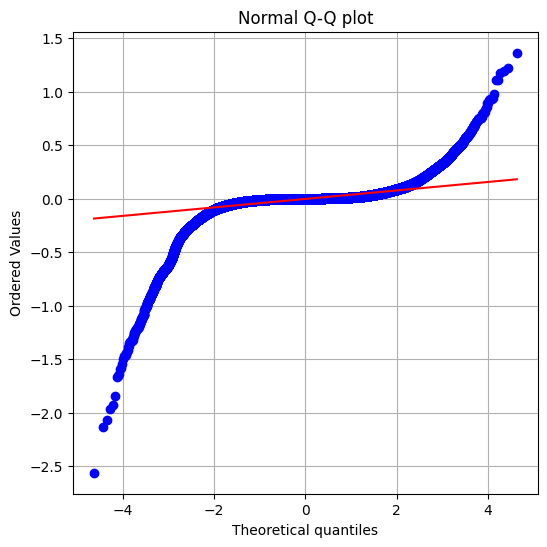

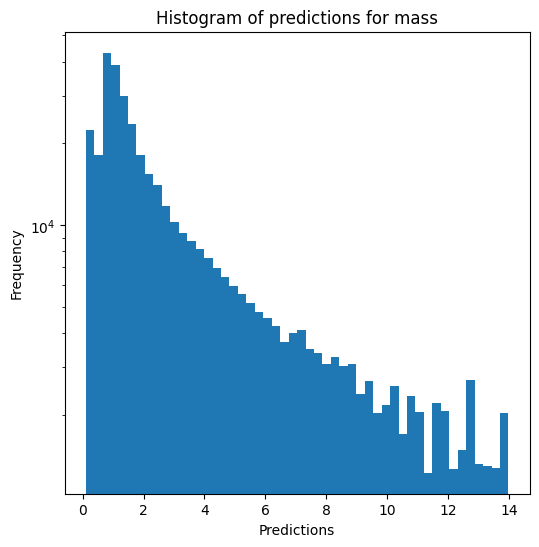

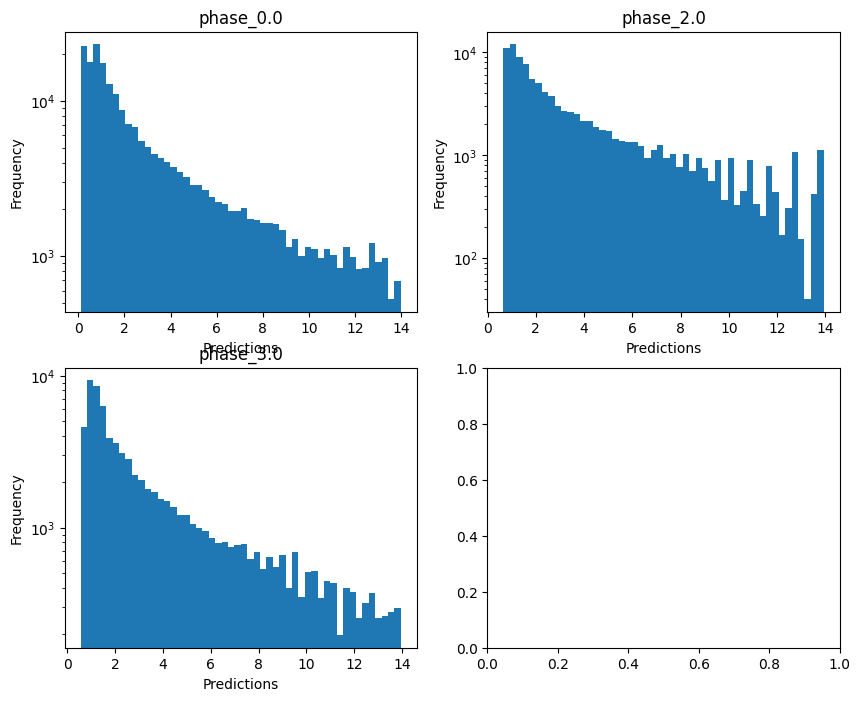


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9999139872241282
  RMSE :  0.003906955768793368
  MAE :  0.002544352496218173
  MedAE :  0.0016893257587445032
  CORR :  0.9999573211618505
  MAX_ER :  0.057009571821611704
  Percentiles : 
    75th percentile :  0.002794132613789852
    90th percentile :  0.005585809631184802
    95th percentile :  0.007951734508988666
    99th percentile :  0.015234914501349095

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9999151482883395
  RMSE :  0.004287547811442896
  MAE :  0.0031611422902893954
  MedAE :  0.002241792595786607
  CORR :  0.9999576714231969
  MAX_ER :  0.06367710139367677
  Percentiles : 
    75th percentile :  0.004186060899811439
    90th percentile :  0.007092519795696996
    95th percentile :  0.009059805349270962
    99th percentile :  0.013212676719942404

radius results

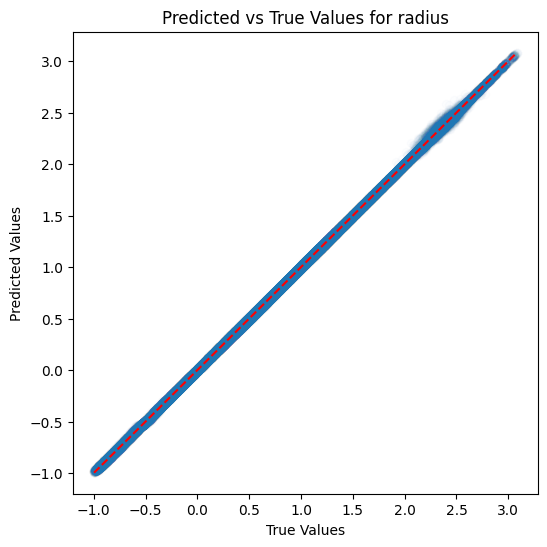

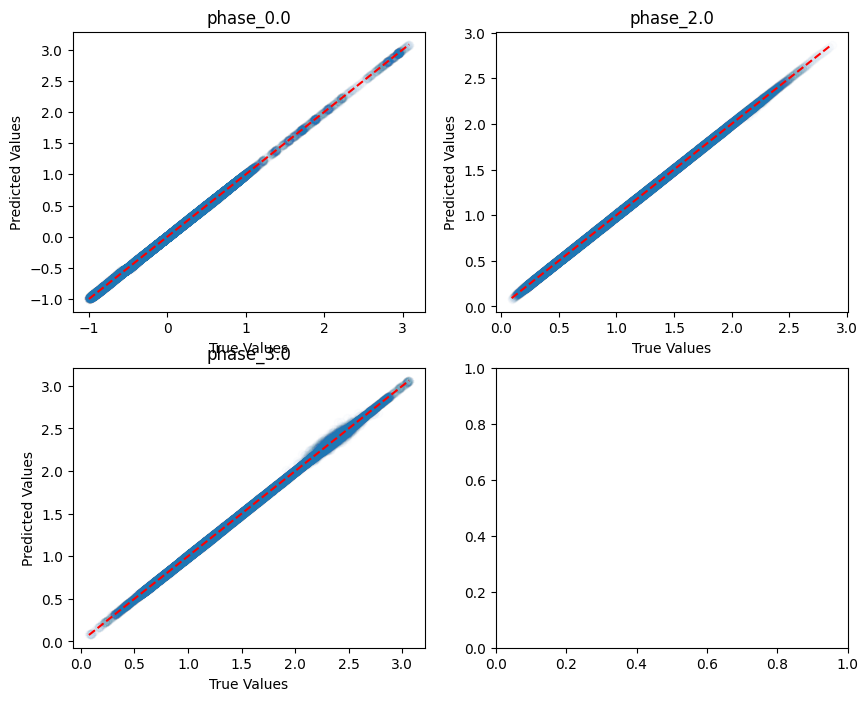

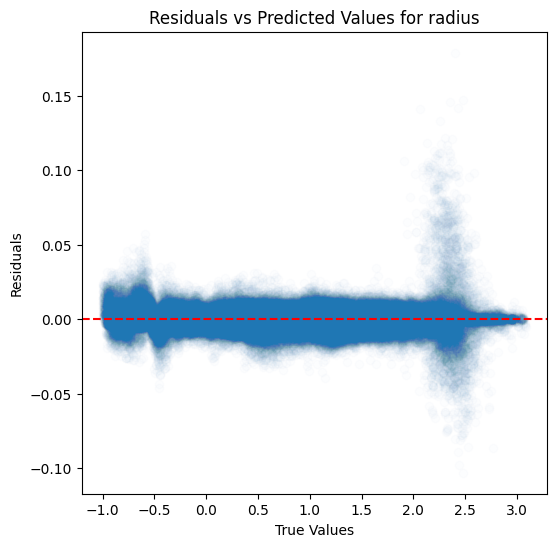

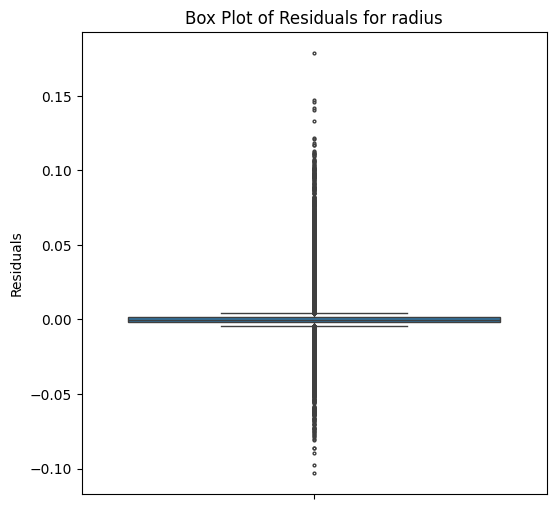

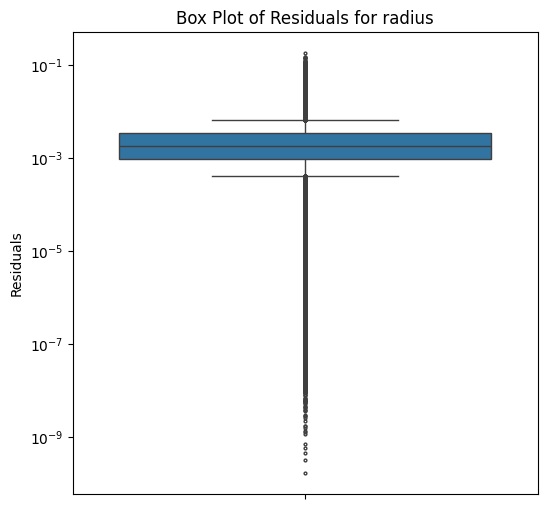

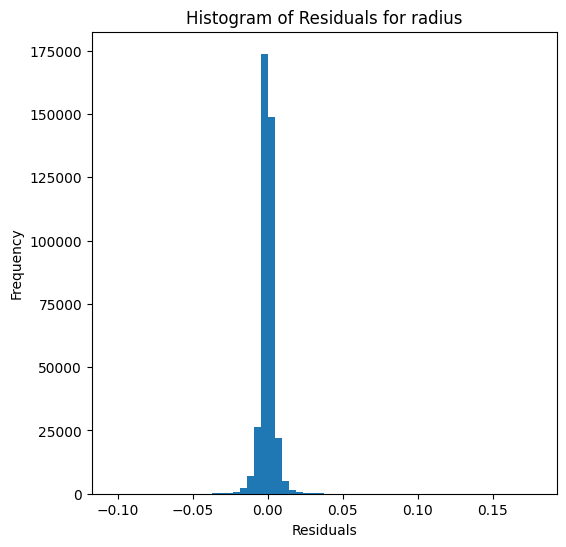

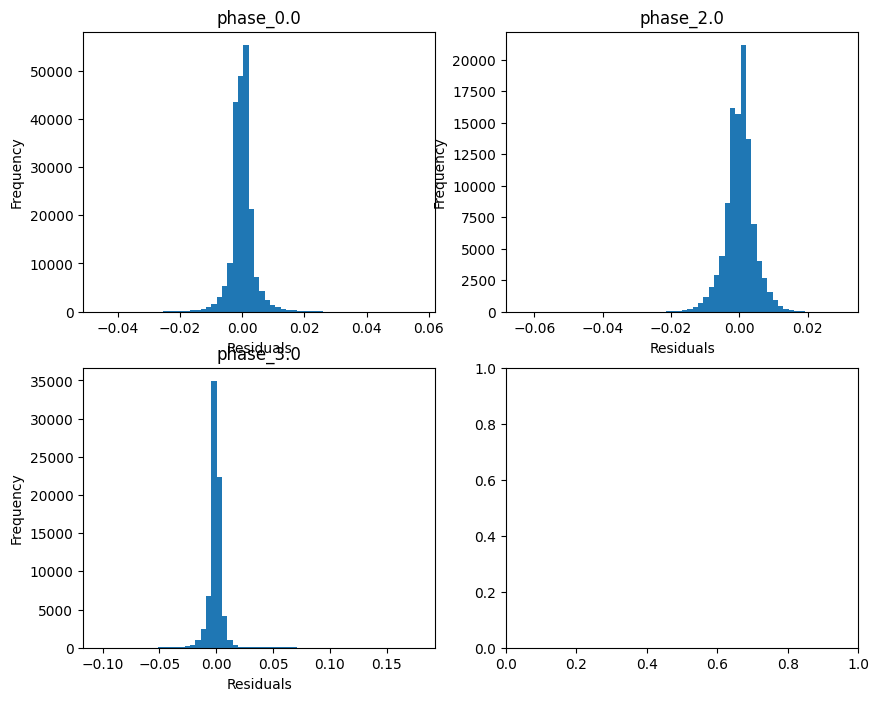

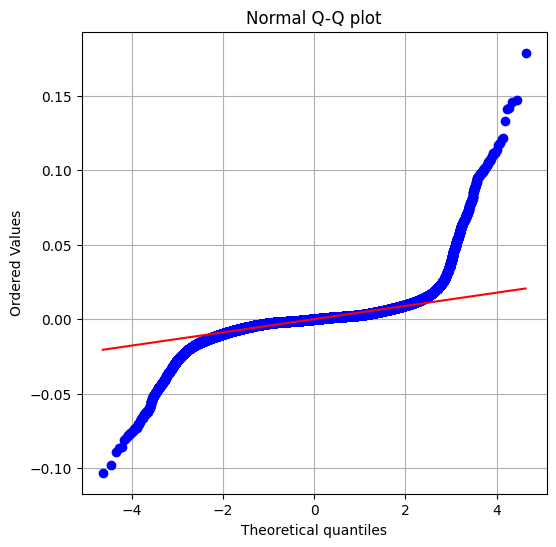

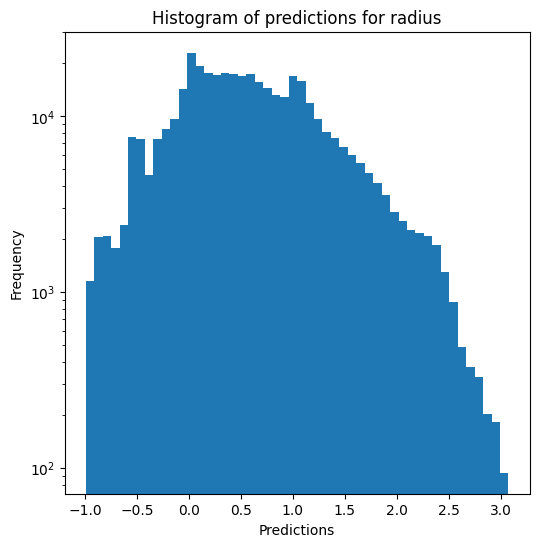

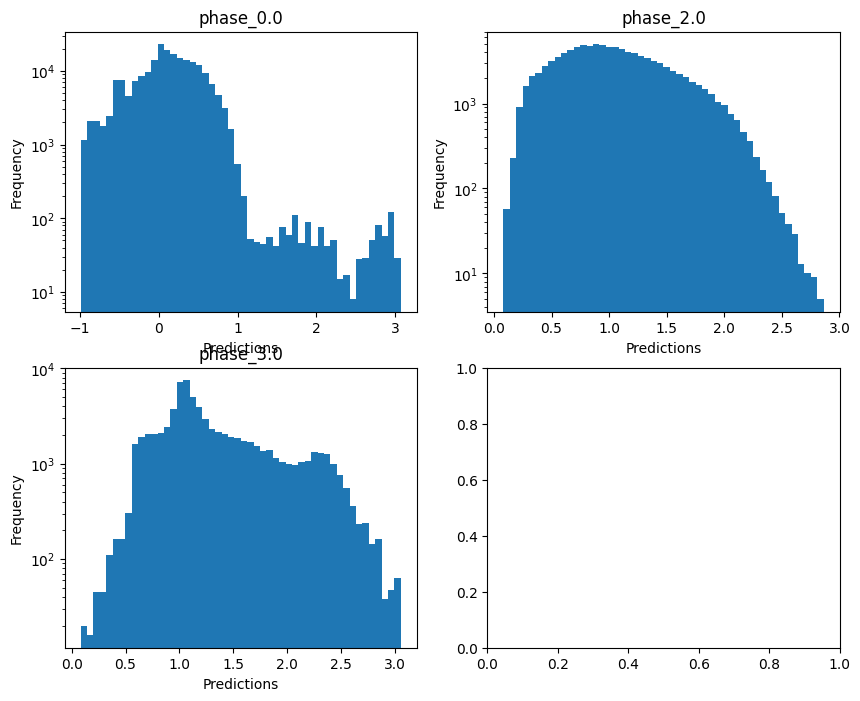

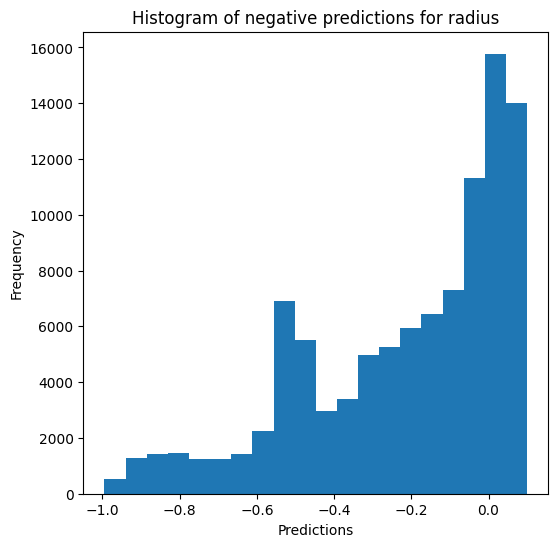

Saving predictions and results...


In [10]:
best_params_KNN = {'n_jobs':10, 'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 5, 'p': 1.0, 'weights': 'distance'}

print(path_to_results)
dt_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
dt_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, **best_params_KNN)

### XGBoost (old)

#### Tuning the booster and n_estimators parameters

In [ ]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'booster': ["gbtree", "dart"],
             'n_estimators': [100, 150, 200, 250, 300]
            }

gscv_xgb_1 = GridSearchCV(XGBRegressor(),
                          param_grid = cv_params,
                          scoring = scoring,
                          cv = 10,
                          verbose = 2,
                          n_jobs = 10,
                          refit="neg_root_mean_squared_error"
)

gscv_xgb_1.fit(X_train,y_train)
display_grid_search(gscv_xgb_1)

Fitting 10 folds for each of 10 candidates, totalling 100 fits
{'mean_fit_time': array([  20.69389312,   29.18247805,   38.35277479,   47.2308882 ,
         60.62191837,  356.08439801,  895.44667237, 1507.51369855,
       2402.25628304, 3366.69091668]), 'std_fit_time': array([0.07769418, 0.06070511, 0.13790512, 0.22198645, 0.30830806,
       0.85301046, 0.74887913, 1.29224332, 1.59952764, 1.82418495]), 'mean_score_time': array([0.26689737, 0.39263556, 0.5014365 , 0.6506825 , 0.76257923,
       1.46083403, 2.28069382, 2.9225358 , 3.89363177, 4.24273353]), 'std_score_time': array([0.0108491 , 0.01546095, 0.03380829, 0.0486309 , 0.03812669,
       0.01652387, 0.05503893, 0.04087245, 0.02967931, 0.33853908]), 'param_booster': masked_array(data=['gbtree', 'gbtree', 'gbtree', 'gbtree', 'gbtree',
                   'dart', 'dart', 'dart', 'dart', 'dart'],
             mask=[False, False, False, False, False, False, False, False,
                   False, False],
       fill_value=np.str_('?')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_booster,param_n_estimators,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,...,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,20.693893,0.077694,0.266897,0.010849,gbtree,100,"{'booster': 'gbtree', 'n_estimators': 100}",-0.862622,-0.815595,-0.833992,...,-0.210185,-0.206682,-0.205544,-0.212830,-0.211501,-0.215420,-0.205422,-0.208992,0.003579,9
1,29.182478,0.060705,0.392636,0.015461,gbtree,150,"{'booster': 'gbtree', 'n_estimators': 150}",-0.771157,-0.735993,-0.758892,...,-0.192054,-0.189733,-0.189802,-0.193274,-0.190086,-0.196253,-0.189847,-0.191225,0.002417,7
2,38.352775,0.137905,0.501436,0.033808,gbtree,200,"{'booster': 'gbtree', 'n_estimators': 200}",-0.721268,-0.696496,-0.721882,...,-0.178115,-0.173815,-0.177536,-0.180543,-0.177889,-0.179410,-0.177139,-0.177351,0.002094,5
3,47.230888,0.221986,0.650682,0.048631,gbtree,250,"{'booster': 'gbtree', 'n_estimators': 250}",-0.693030,-0.667542,-0.696751,...,-0.168372,-0.164750,-0.167782,-0.169838,-0.166401,-0.170032,-0.168284,-0.167540,0.002249,4
4,60.621918,0.308308,0.762579,0.038127,gbtree,300,"{'booster': 'gbtree', 'n_estimators': 300}",-0.676538,-0.652146,-0.683637,...,-0.161682,-0.156509,-0.158714,-0.162931,-0.157452,-0.158893,-0.159840,-0.159277,0.002054,1
5,356.084398,0.853010,1.460834,0.016524,dart,100,"{'booster': 'dart', 'n_estimators': 100}",-0.862622,-0.815595,-0.833992,...,-0.210185,-0.206682,-0.205544,-0.212830,-0.211501,-0.215420,-0.205422,-0.208992,0.003579,10
6,895.446672,0.748879,2.280694,0.055039,dart,150,"{'booster': 'dart', 'n_estimators': 150}",-0.771157,-0.735993,-0.758892,...,-0.192054,-0.189733,-0.189802,-0.193274,-0.190086,-0.196253,-0.189847,-0.191225,0.002417,8
7,1507.513699,1.292243,2.922536,0.040872,dart,200,"{'booster': 'dart', 'n_estimators': 200}",-0.721268,-0.696496,-0.721882,...,-0.178115,-0.173815,-0.177536,-0.180543,-0.177889,-0.179410,-0.177139,-0.177351,0.002094,6
8,2402.256283,1.599528,3.893632,0.029679,dart,250,"{'booster': 'dart', 'n_estimators': 250}",-0.693030,-0.667542,-0.696751,...,-0.168372,-0.164750,-0.167782,-0.169838,-0.166401,-0.170032,-0.168284,-0.167540,0.002249,3
9,3366.690917,1.824185,4.242734,0.338539,dart,300,"{'booster': 'dart', 'n_estimators': 300}",-0.676538,-0.652145,-0.683637,...,-0.161682,-0.156509,-0.158714,-0.162931,-0.157452,-0.158893,-0.159840,-0.159277,0.002054,2


Best parameters {'booster': 'dart', 'n_estimators': 300}
Best score -0.6922802578352828


The results are the same with gbtree and dart, but dart takes a lot longer to train. We will choose gbtree.

More estimators improves the results, we will test with more estimators to try and find the limit at which adding more estimators does not improve the results much

In [ ]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
            }

gscv_xgb_2 = GridSearchCV(XGBRegressor(),
                          param_grid = cv_params,
                          scoring = scoring,
                          cv = 10,
                          verbose = 2,
                          n_jobs = 10,
                          refit="neg_root_mean_squared_error"
)

gscv_xgb_2.fit(X_train,y_train)
display_grid_search(gscv_xgb_2)

Fitting 10 folds for each of 10 candidates, totalling 100 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,23.188663,0.054305,0.309838,0.005001,100,{'n_estimators': 100},-0.862622,-0.815595,-0.833992,-0.922820,-0.806739,-0.840190,-0.906333,-0.885421,-0.863118,-0.859691,-0.859652,0.035542,10,-0.208420,-0.203369,-0.210545,-0.210185,-0.206682,-0.205544,-0.212830,-0.211501,-0.215420,-0.205422,-0.208992,0.003579,10
1,41.873128,0.081130,0.587952,0.020353,200,{'n_estimators': 200},-0.721268,-0.696496,-0.721882,-0.773427,-0.690349,-0.740011,-0.776199,-0.735422,-0.740602,-0.746947,-0.734261,0.026842,9,-0.176690,-0.173655,-0.178720,-0.178115,-0.173815,-0.177536,-0.180543,-0.177889,-0.179410,-0.177139,-0.177351,0.002094,9
2,61.729190,0.149665,0.899116,0.037464,300,{'n_estimators': 300},-0.676538,-0.652146,-0.683637,-0.732628,-0.655791,-0.701772,-0.730894,-0.683911,-0.694332,-0.711155,-0.692280,0.026276,8,-0.159807,-0.156271,-0.160673,-0.161682,-0.156509,-0.158714,-0.162931,-0.157452,-0.158893,-0.159840,-0.159277,0.002054,8
3,81.396047,0.335990,1.383533,0.231670,400,{'n_estimators': 400},-0.650200,-0.631599,-0.663830,-0.703355,-0.637217,-0.682803,-0.709816,-0.655156,-0.672806,-0.689042,-0.669583,0.025358,7,-0.145691,-0.141360,-0.149428,-0.150069,-0.145260,-0.147627,-0.151945,-0.146064,-0.146950,-0.148499,-0.147289,0.002811,7
4,104.162949,0.490535,1.824301,0.408042,500,{'n_estimators': 500},-0.639257,-0.620956,-0.652298,-0.691265,-0.627228,-0.669581,-0.697537,-0.637327,-0.656773,-0.677557,-0.656978,0.025115,6,-0.140537,-0.134796,-0.143062,-0.141697,-0.138561,-0.140390,-0.144713,-0.137443,-0.138558,-0.140161,-0.139992,0.002696,6
5,124.983232,0.643087,2.361561,0.498340,600,{'n_estimators': 600},-0.633533,-0.612262,-0.640113,-0.685095,-0.622929,-0.660232,-0.689994,-0.631423,-0.652140,-0.670570,-0.649829,0.024969,5,-0.134402,-0.128508,-0.135870,-0.134720,-0.133726,-0.133314,-0.138347,-0.132661,-0.132750,-0.133764,-0.133806,0.002384,5
6,149.172118,0.717782,2.568778,0.636161,700,{'n_estimators': 700},-0.625569,-0.607863,-0.635133,-0.678575,-0.621181,-0.656236,-0.683569,-0.623403,-0.647427,-0.666657,-0.644561,0.024702,4,-0.127931,-0.124243,-0.129584,-0.129468,-0.128005,-0.128883,-0.132949,-0.127380,-0.128463,-0.128889,-0.128580,0.002052,4
7,158.095074,0.829726,3.024416,0.688507,800,{'n_estimators': 800},-0.619412,-0.603376,-0.631713,-0.675529,-0.619744,-0.652375,-0.680038,-0.620967,-0.643814,-0.665387,-0.641236,0.025037,3,-0.123464,-0.119408,-0.125406,-0.125477,-0.124861,-0.124767,-0.129388,-0.124073,-0.124972,-0.125587,-0.124740,0.002321,3
8,183.922738,0.963922,3.386511,0.884478,900,{'n_estimators': 900},-0.615941,-0.598248,-0.629587,-0.672776,-0.617748,-0.650625,-0.676012,-0.623025,-0.640578,-0.663642,-0.638818,0.024986,2,-0.119969,-0.116792,-0.122607,-0.122258,-0.121810,-0.121831,-0.125797,-0.121346,-0.122070,-0.122294,-0.121677,0.002136,2
9,205.257477,1.193017,3.881280,1.014430,1000,{'n_estimators': 1000},-0.614386,-0.597441,-0.626765,-0.671549,-0.616147,-0.648618,-0.674653,-0.620786,-0.639574,-0.662538,-0.

Best parameters {'n_estimators': 1000}
Best score -0.6372457587758518


600 estimators seem to be the place where adding more estimators does not improve the results a lot which is why we will use this value.

#### Tuning the max_depth and min_child_weight parameters

In [ ]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'max_depth': [10, 30, 50],
             'min_child_weight': [3, 6, 9]
            }

gscv_xgb_3 = GridSearchCV(XGBRegressor(n_estimators=600
                                       ),
                          param_grid = cv_params,
                          scoring = scoring,
                          cv = 10,
                          verbose = 2,
                          n_jobs = 10,
                          refit="neg_root_mean_squared_error"
)

gscv_xgb_3.fit(X_train,y_train)
display_grid_search(gscv_xgb_3)

Fitting 10 folds for each of 9 candidates, totalling 90 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_child_weight,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,216.996130,0.667281,7.282642,0.210698,10,3,"{'max_depth': 10, 'min_child_weight': 3}",-0.634528,-0.595696,-0.637307,-0.670742,-0.631100,-0.640625,-0.679338,-0.646013,-0.654347,-0.662486,-0.645218,0.022467,3,-0.090922,-0.087347,-0.093305,-0.093200,-0.092961,-0.091628,-0.093329,-0.093083,-0.094030,-0.093421,-0.092322,0.001872,7
1,201.464543,0.260862,6.658354,0.262661,10,6,"{'max_depth': 10, 'min_child_weight': 6}",-0.622431,-0.593026,-0.635545,-0.667754,-0.606278,-0.627444,-0.673003,-0.631883,-0.637604,-0.655768,-0.635073,0.024014,2,-0.092993,-0.090635,-0.095627,-0.095805,-0.094347,-0.093698,-0.096905,-0.094916,-0.096746,-0.095710,-0.094738,0.001810,8
2,203.622309,0.382889,6.067565,0.259780,10,9,"{'max_depth': 10, 'min_child_weight': 9}",-0.606851,-0.580455,-0.615109,-0.662099,-0.593661,-0.624549,-0.671083,-0.619358,-0.629215,-0.642587,-0.624497,0.026926,1,-0.094203,-0.091317,-0.096500,-0.098620,-0.095554,-0.095683,-0.098610,-0.096922,-0.097954,-0.097792,-0.096315,0.002151,9
3,353.765994,7.179277,20.134031,2.577491,30,3,"{'max_depth': 30, 'min_child_weight': 3}",-0.670135,-0.627377,-0.659862,-0.701313,-0.665351,-0.684749,-0.712138,-0.665009,-0.659563,-0.701340,-0.674684,0.024107,8,-0.084372,-0.080872,-0.086112,-0.086548,-0.086458,-0.085749,-0.086865,-0.085664,-0.086724,-0.087251,-0.085662,0.001770,6
4,453.526178,6.614705,37.690233,4.308708,30,6,"{'max_depth': 30, 'min_child_weight': 6}",-0.660757,-0.624293,-0.659833,-0.692973,-0.633186,-0.667832,-0.695514,-0.649037,-0.658476,-0.667054,-0.660896,0.021374,6,-0.083676,-0.081293,-0.086346,-0.086655,-0.085074,-0.085242,-0.086272,-0.084971,-0.087149,-0.086149,-0.085283,0.001639,4
5,430.583238,5.041421,40.415308,4.444990,30,9,"{'max_depth': 30, 'min_child_weight': 9}",-0.648864,-0.614550,-0.644799,-0.691672,-0.641208,-0.644558,-0.681922,-0.644334,-0.646199,-0.674072,-0.653218,0.021610,5,-0.083471,-0.080895,-0.085753,-0.086411,-0.085308,-0.084141,-0.085761,-0.084794,-0.086464,-0.087104,-0.085010,0.001726,2
6,373.085914,4.543448,27.919495,1.851947,50,3,"{'max_depth': 50, 'min_child_weight': 3}",-0.673901,-0.625940,-0.660902,-0.701331,-0.664841,-0.685445,-0.714674,-0.666376,-0.659631,-0.704262,-0.675730,0.024996,9,-0.084407,-0.080633,-0.086152,-0.086564,-0.086359,-0.085645,-0.086755,-0.085768,-0.086693,-0.087416,-0.085639,0.001837,5
7,508.846024,5.407818,45.821680,6.532356,50,6,"{'max_depth': 50, 'min_child_weight': 6}",-0.662593,-0.620849,-0.662466,-0.694651,-0.635007,-0.669380,-0.693050,-0.647182,-0.658117,-0.668568,-0.661186,0.021860,7,-0.083623,-0.081006,-0.086667,-0.086418,-0.085034,-0.085149,-0.086112,-0.084633,-0.087125,-0.086212,-0.085198,0.001721,3
8,603.883579,8.063307,44.362552,10.541659,50,9,"{'max_depth': 50, 'min_child_weight': 9}",-0.645829,-0.610272,-0.642087,-0.692493,-0.644174,-0.646492,-0.682432,-0.640201,-0.648872,-0.677095,-0.652995,0.023030,4,-0.083375,-0.080499,-0.085306,-0.086304,-0.085422,-0.084364,-0.08

Best parameters {'max_depth': 10, 'min_child_weight': 9}
Best score -0.6244966662720265


The best value for max_depth is 10 and the best value for min_child_weight is 9.

We will try with some values close to these to see if it could improve again.

In [9]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'max_depth': [5, 10, 15],
             'min_child_weight': [7, 9, 11]
            }

gscv_xgb_4 = GridSearchCV(XGBRegressor(n_estimators=600
                                       ),
                          param_grid = cv_params,
                          scoring = scoring,
                          cv = 10,
                          verbose = 2,
                          n_jobs = 10,
                          refit="neg_root_mean_squared_error"
)

gscv_xgb_4.fit(X_train,y_train)
display_grid_search(gscv_xgb_4)

Fitting 10 folds for each of 9 candidates, totalling 90 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_child_weight,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,106.784186,0.192435,1.376540,0.047841,5,7,"{'max_depth': 5, 'min_child_weight': 7}",-0.669447,-0.639113,-0.678551,-0.737957,-0.645755,-0.687489,-0.728376,-0.688914,-0.690396,-0.689259,-0.685526,0.029464,7,-0.161120,-0.156023,-0.161402,-0.166617,-0.162963,-0.162608,-0.170854,-0.164197,-0.165063,-0.163447,-0.163429,0.003657,7
1,106.647101,0.123905,1.414989,0.049719,5,9,"{'max_depth': 5, 'min_child_weight': 9}",-0.665721,-0.650348,-0.685258,-0.740456,-0.634597,-0.696982,-0.742319,-0.687772,-0.690365,-0.696986,-0.689080,0.032605,9,-0.163281,-0.158904,-0.166423,-0.168412,-0.160932,-0.161614,-0.169727,-0.165232,-0.164426,-0.164877,-0.164383,0.003174,8
2,105.658470,0.085190,1.440369,0.029395,5,11,"{'max_depth': 5, 'min_child_weight': 11}",-0.661000,-0.650502,-0.676456,-0.731214,-0.637289,-0.686031,-0.727150,-0.693040,-0.698140,-0.694565,-0.685539,0.028905,8,-0.164219,-0.159845,-0.166491,-0.167177,-0.163940,-0.162284,-0.171037,-0.166317,-0.165231,-0.164264,-0.165080,0.002852,9
3,193.475243,0.512021,6.110822,0.266172,10,7,"{'max_depth': 10, 'min_child_weight': 7}",-0.604746,-0.588734,-0.617113,-0.663325,-0.607259,-0.619760,-0.676219,-0.635037,-0.628015,-0.644275,-0.628448,0.025660,3,-0.092999,-0.090913,-0.095334,-0.096010,-0.094155,-0.094144,-0.097358,-0.096154,-0.096951,-0.095919,-0.094994,0.001866,4
4,194.799605,0.372675,5.767778,0.306135,10,9,"{'max_depth': 10, 'min_child_weight': 9}",-0.606851,-0.580455,-0.615109,-0.662099,-0.593661,-0.624549,-0.671083,-0.619358,-0.629215,-0.642587,-0.624497,0.026926,2,-0.094203,-0.091317,-0.096500,-0.098620,-0.095554,-0.095683,-0.098610,-0.096922,-0.097954,-0.097792,-0.096315,0.002151,5
5,188.071355,0.413482,5.738239,0.284298,10,11,"{'max_depth': 10, 'min_child_weight': 11}",-0.601059,-0.580502,-0.610775,-0.667299,-0.583279,-0.611232,-0.667352,-0.617674,-0.618154,-0.642585,-0.619991,0.029030,1,-0.095489,-0.092213,-0.096880,-0.099423,-0.096064,-0.094994,-0.099444,-0.097707,-0.097558,-0.099266,-0.096904,0.002186,6
6,207.991583,1.843009,10.665557,0.747766,15,7,"{'max_depth': 15, 'min_child_weight': 7}",-0.635853,-0.617366,-0.643172,-0.698571,-0.638061,-0.652374,-0.702651,-0.651071,-0.652365,-0.666948,-0.655843,0.025581,6,-0.085414,-0.082990,-0.087891,-0.088594,-0.087218,-0.087107,-0.088905,-0.087745,-0.089070,-0.088262,-0.087320,0.001762,1
7,215.266734,2.063044,12.187842,0.921054,15,9,"{'max_depth': 15, 'min_child_weight': 9}",-0.626149,-0.605954,-0.627986,-0.678188,-0.638740,-0.636108,-0.682829,-0.634146,-0.654195,-0.664266,-0.644856,0.023224,5,-0.085402,-0.083382,-0.087285,-0.088559,-0.087861,-0.087053,-0.088854,-0.087644,-0.089509,-0.089268,-0.087482,0.001785,2
8,220.539799,2.182575,10.463426,1.432838,15,11,"{'max_depth': 15, 'min_child_weight': 11}",-0.628371,-0.599333,-0.631173,-0.692598,-0.622697,-0.632638,-0.667782,-0.629009,-0.631299,-0.653294,-0.638820,0.024735,4,-0.086156,-0.083372,-0.088781,-0.090052,-0.087974,-0.087283,-0.088681

Best parameters {'max_depth': 10, 'min_child_weight': 11}
Best score -0.6199912998531577


The best value for max_septh is still 10 and the best value for min_child_weight is 11.

#### Tuning the gamma and subsample parameters

In [11]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'gamma': [0, 5, 10],
             'subsample': [0.6, 0.8, 1]
            }

gscv_xgb_5 = GridSearchCV(XGBRegressor(n_estimators=600,
                                       max_depth=10,
                                       min_child_weight=11
                                       ),
                          param_grid = cv_params,
                          scoring = scoring,
                          cv = 10,
                          verbose = 2,
                          n_jobs = 10,
                          refit="neg_root_mean_squared_error"
)

gscv_xgb_5.fit(X_train,y_train)
display_grid_search(gscv_xgb_5)

Fitting 10 folds for each of 9 candidates, totalling 90 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_gamma,param_subsample,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,187.172328,0.450454,5.392413,0.188188,0,0.6,"{'gamma': 0, 'subsample': 0.6}",-0.596287,-0.604860,-0.630138,-0.675059,-0.609851,-0.628479,-0.682349,-0.621809,-0.641488,-0.662437,-0.635276,0.028143,3,-0.108571,-0.107293,-0.110917,-0.112428,-0.109618,-0.110885,-0.114421,-0.110120,-0.111813,-0.111559,-0.110763,0.001911,3
1,185.706425,0.528340,5.526351,0.328064,0,0.8,"{'gamma': 0, 'subsample': 0.8}",-0.592654,-0.597271,-0.635049,-0.677635,-0.613254,-0.627672,-0.671004,-0.621833,-0.628795,-0.655115,-0.632028,0.027176,2,-0.106661,-0.103697,-0.109588,-0.109017,-0.108337,-0.106626,-0.110493,-0.108539,-0.108888,-0.109975,-0.108182,0.001916,2
2,185.185837,0.975129,5.971166,0.725376,0,1.0,"{'gamma': 0, 'subsample': 1}",-0.601059,-0.580502,-0.610775,-0.667299,-0.583279,-0.611232,-0.667352,-0.617674,-0.618154,-0.642585,-0.619991,0.029030,1,-0.095489,-0.092213,-0.096880,-0.099423,-0.096064,-0.094994,-0.099444,-0.097707,-0.097558,-0.099266,-0.096904,0.002186,1
3,69.285660,0.299034,1.655154,0.061629,5,0.6,"{'gamma': 5, 'subsample': 0.6}",-0.622166,-0.614589,-0.656914,-0.683802,-0.632825,-0.641712,-0.699321,-0.643449,-0.660606,-0.684862,-0.654025,0.026878,4,-0.129625,-0.126409,-0.133040,-0.132417,-0.131234,-0.130338,-0.135452,-0.130433,-0.133532,-0.133040,-0.131552,0.002394,5
4,63.485081,0.550443,1.567022,0.118088,5,0.8,"{'gamma': 5, 'subsample': 0.8}",-0.632578,-0.622262,-0.659197,-0.697720,-0.634045,-0.650963,-0.689858,-0.643311,-0.660848,-0.669928,-0.656071,0.023388,5,-0.128404,-0.125604,-0.131779,-0.131257,-0.130159,-0.130325,-0.132323,-0.130210,-0.131860,-0.131321,-0.130324,0.001906,4
5,33.509696,1.387873,0.653989,0.012449,5,1.0,"{'gamma': 5, 'subsample': 1}",-0.712373,-0.680022,-0.684056,-0.771815,-0.648829,-0.698536,-0.760117,-0.697004,-0.716134,-0.727569,-0.709645,0.035068,8,-0.137270,-0.134472,-0.138545,-0.140966,-0.136808,-0.137239,-0.141706,-0.138761,-0.138114,-0.138237,-0.138212,0.001950,8
6,64.501837,0.685447,1.507222,0.035716,10,0.6,"{'gamma': 10, 'subsample': 0.6}",-0.641621,-0.626823,-0.661031,-0.688601,-0.633752,-0.652030,-0.700148,-0.652674,-0.670069,-0.682104,-0.660885,0.022930,6,-0.136673,-0.133979,-0.139406,-0.139103,-0.136479,-0.137083,-0.141528,-0.137800,-0.139666,-0.139146,-0.138086,0.002019,7
7,57.910251,0.798399,1.441373,0.146364,10,0.8,"{'gamma': 10, 'subsample': 0.8}",-0.636756,-0.628122,-0.669989,-0.703464,-0.635274,-0.661223,-0.713914,-0.650343,-0.663261,-0.679795,-0.664214,0.027172,7,-0.134793,-0.132080,-0.139608,-0.138568,-0.136073,-0.135992,-0.140474,-0.135867,-0.137586,-0.138026,-0.136907,0.002342,6
8,31.788703,0.531660,0.529293,0.085073,10,1.0,"{'gamma': 10, 'subsample': 1}",-0.727535,-0.691906,-0.709632,-0.789944,-0.687399,-0.721240,-0.799418,-0.717811,-0.721117,-0.760877,-0.732688,0.036448,9,-0.142784,-0.138740,-0.144809,-0.146443,-0.145218,-0.142631,-0.150081,-0.143708,-0.143755,-0.144718,-0.144289,0.002756,9


Best parameters {'gamma': 0, 'subsample': 1}
Best score -0.6199912998531577


In [12]:
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE

cv_params = {'gamma': [0, 1, 2, 3],
             'subsample': [0.9, 0.95, 1]
            }

gscv_xgb_6 = GridSearchCV(XGBRegressor(n_estimators=600,
                                       max_depth=10,
                                       min_child_weight=11
                                       ),
                          param_grid = cv_params,
                          scoring = scoring,
                          cv = 10,
                          verbose = 2,
                          n_jobs = 10,
                          refit="neg_root_mean_squared_error"
)

gscv_xgb_6.fit(X_train,y_train)
display_grid_search(gscv_xgb_6)

Fitting 10 folds for each of 12 candidates, totalling 120 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_gamma,param_subsample,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,177.543278,0.204183,5.066539,0.090761,0,0.90,"{'gamma': 0, 'subsample': 0.9}",-0.594379,-0.610800,-0.624819,-0.675266,-0.615806,-0.625126,-0.674407,-0.625055,-0.626205,-0.653981,-0.632584,0.025412,2,-0.103343,-0.103097,-0.106468,-0.107910,-0.106444,-0.106181,-0.108199,-0.107671,-0.107212,-0.107158,-0.106368,0.001693,3
1,176.862445,0.415271,5.340614,0.185722,0,0.95,"{'gamma': 0, 'subsample': 0.95}",-0.605546,-0.598342,-0.634253,-0.671586,-0.612217,-0.625641,-0.677072,-0.625422,-0.636847,-0.643863,-0.633079,0.024625,3,-0.102545,-0.100898,-0.105981,-0.106100,-0.104266,-0.104314,-0.107789,-0.105572,-0.106270,-0.106067,-0.104980,0.001921,2
2,180.920303,0.577972,5.643361,0.392116,0,1.00,"{'gamma': 0, 'subsample': 1}",-0.601059,-0.580502,-0.610775,-0.667299,-0.583279,-0.611232,-0.667352,-0.617674,-0.618154,-0.642585,-0.619991,0.029030,1,-0.095489,-0.092213,-0.096880,-0.099423,-0.096064,-0.094994,-0.099444,-0.097707,-0.097558,-0.099266,-0.096904,0.002186,1
3,70.179544,0.279231,1.746951,0.054955,1,0.90,"{'gamma': 1, 'subsample': 0.9}",-0.615308,-0.619919,-0.639357,-0.688266,-0.627013,-0.636536,-0.680589,-0.635402,-0.645520,-0.657495,-0.644541,0.023071,4,-0.116376,-0.116602,-0.119917,-0.120684,-0.118808,-0.118499,-0.120911,-0.119713,-0.121289,-0.120455,-0.119325,0.001645,4
4,65.640936,0.275100,1.660878,0.102526,1,0.95,"{'gamma': 1, 'subsample': 0.95}",-0.623255,-0.611643,-0.649329,-0.678334,-0.625032,-0.632771,-0.683437,-0.637166,-0.658384,-0.656721,-0.645607,0.022617,5,-0.118326,-0.114907,-0.121611,-0.121325,-0.120597,-0.119211,-0.122730,-0.119705,-0.122266,-0.121302,-0.120198,0.002192,5
5,37.371334,0.700298,0.769283,0.028351,1,1.00,"{'gamma': 1, 'subsample': 1}",-0.659050,-0.644650,-0.633079,-0.705198,-0.623226,-0.656017,-0.713029,-0.646370,-0.663469,-0.693889,-0.663798,0.028959,10,-0.125578,-0.123872,-0.125907,-0.128109,-0.126228,-0.125741,-0.131624,-0.126046,-0.126763,-0.128530,-0.126840,0.002021,9
6,63.633517,0.339091,1.706438,0.167045,2,0.90,"{'gamma': 2, 'subsample': 0.9}",-0.622844,-0.624292,-0.645751,-0.691210,-0.628765,-0.630673,-0.682862,-0.634358,-0.651482,-0.657894,-0.647013,0.022889,6,-0.121567,-0.120130,-0.124641,-0.125114,-0.123059,-0.121653,-0.125123,-0.123012,-0.124878,-0.124473,-0.123365,0.001677,6
7,58.767001,0.422463,1.623138,0.279692,2,0.95,"{'gamma': 2, 'subsample': 0.95}",-0.629495,-0.622021,-0.646528,-0.687048,-0.621463,-0.641670,-0.693250,-0.645200,-0.664208,-0.655546,-0.650643,0.023651,7,-0.123118,-0.120247,-0.125351,-0.126023,-0.124796,-0.123576,-0.128065,-0.124529,-0.127554,-0.124765,-0.124802,0.002125,7
8,34.079923,1.516981,0.714754,0.028205,2,1.00,"{'gamma': 2, 'subsample': 1}",-0.679416,-0.669142,-0.649014,-0.731009,-0.628111,-0.681824,-0.723553,-0.659264,-0.701346,-0.708430,-0.683111,0.031417,11,-0.130043,-0.129380,-0.130603,-0.132262,-0.129947,-0.131918,-0.133509,-0.129453,-0.133581,-0.132194,-0.131289,0.001523,11
9,60.289977,0.990865,1.551760,0.161176,3

Best parameters {'gamma': 0, 'subsample': 1}
Best score -0.6199912998531577


The best parameters for gamma is 0 and for subsample is 1.

We will choose these parameters for the finr tuned model.

#### Training the model with all the fine-tuned parameters and checking the results

../../../../../../../results/model_A/fine_tuned_models/

Base train data :
split 1 2 3 4 5 6 7 8 9 10 
mass results:
RVE :  0.9963555152653054
RMSE :  1.2413188193415403
MAE :  0.18893997760549602
MedAE :  0.03302609418289548
CORR :  0.998176097074924
MAX_ER :  98.20726348645366
Percentiles : 
  75th percentile :  0.08853455989910353
  90th percentile :  0.205054634404997
  95th percentile :  0.38657844017875365
  99th percentile :  3.224239364094813



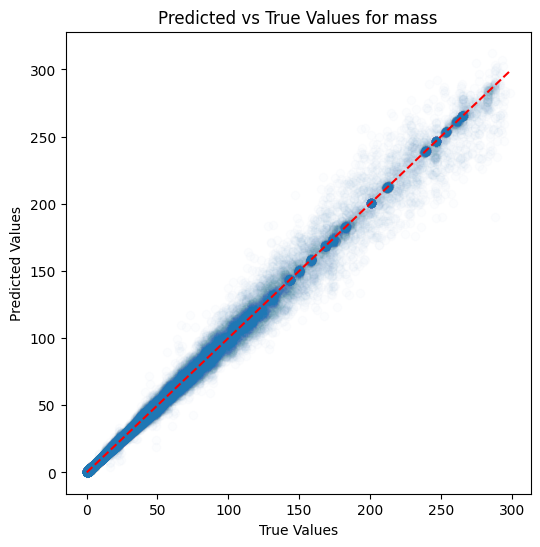

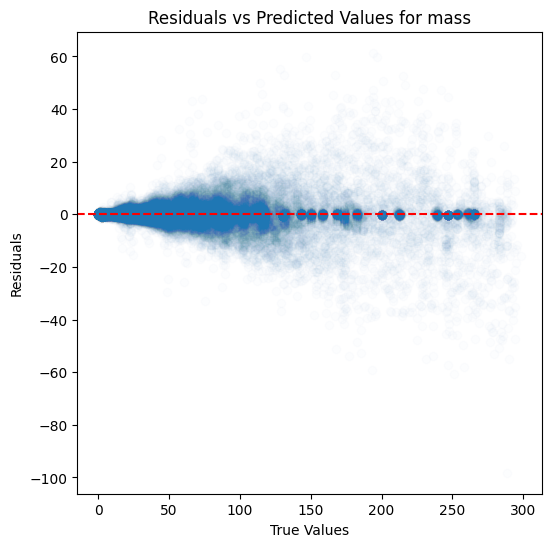

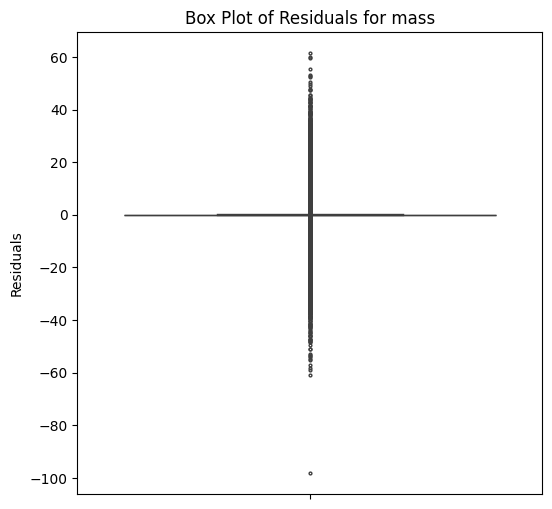

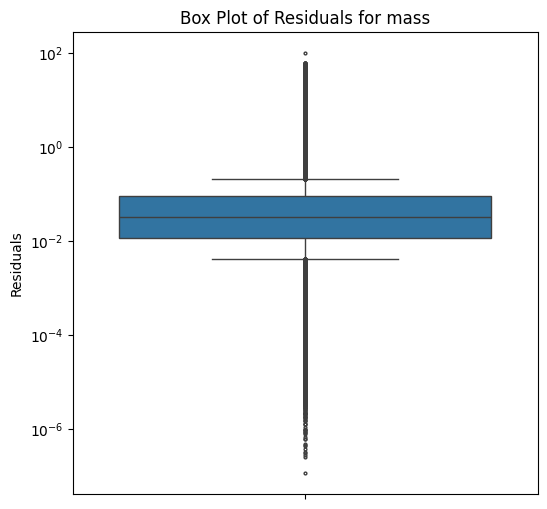

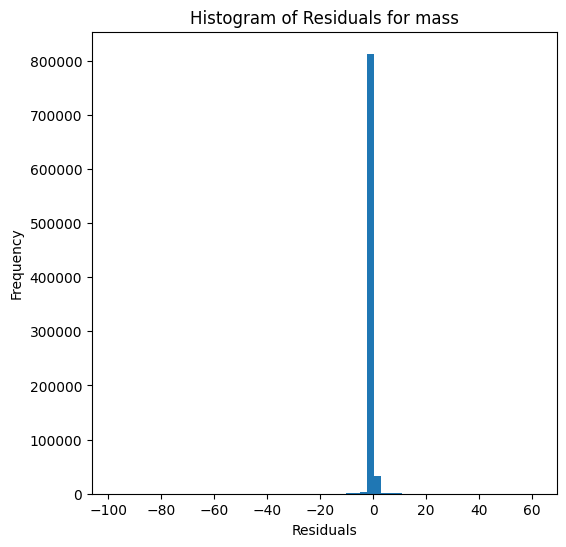

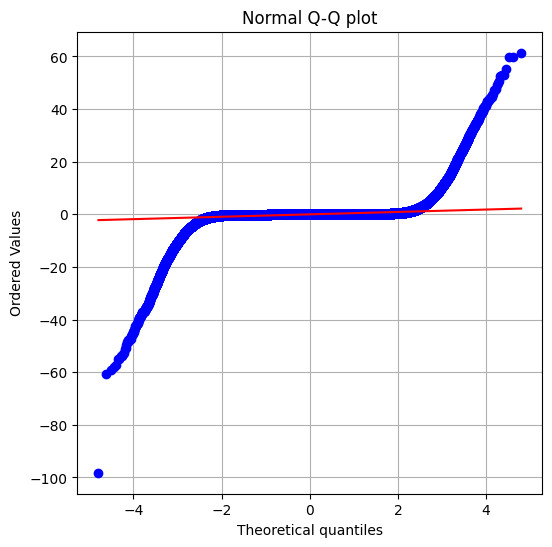

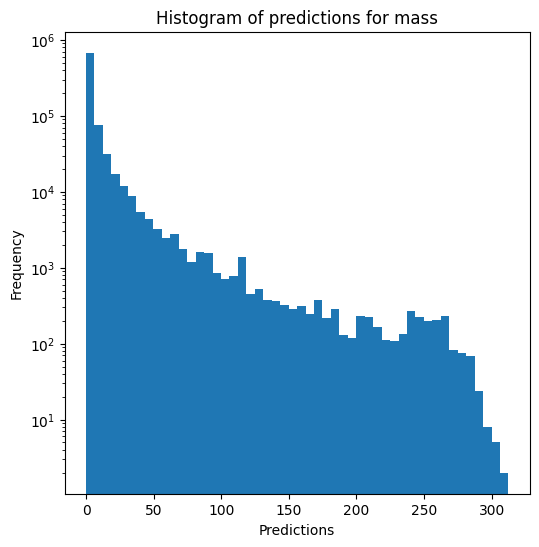

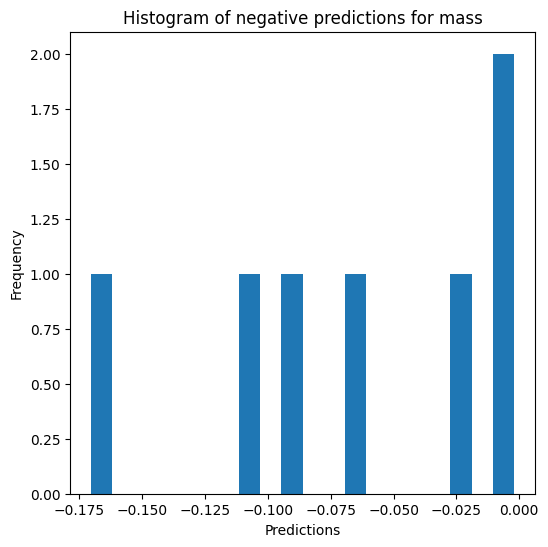


radius results:
RVE :  0.9998793298036383
RMSE :  0.01044114777506761
MAE :  0.006330140390749902
MedAE :  0.004084671235648707
CORR :  0.9999396633545502
MAX_ER :  0.44014824382372864
Percentiles : 
  75th percentile :  0.007696650719609011
  90th percentile :  0.013268710215708768
  95th percentile :  0.01971372347720805
  99th percentile :  0.04175348200022795



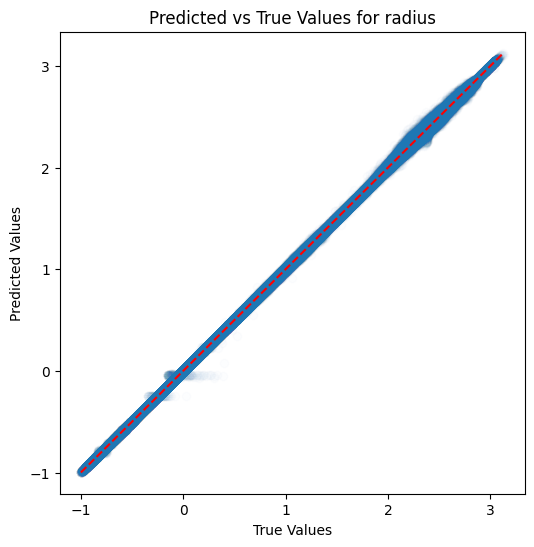

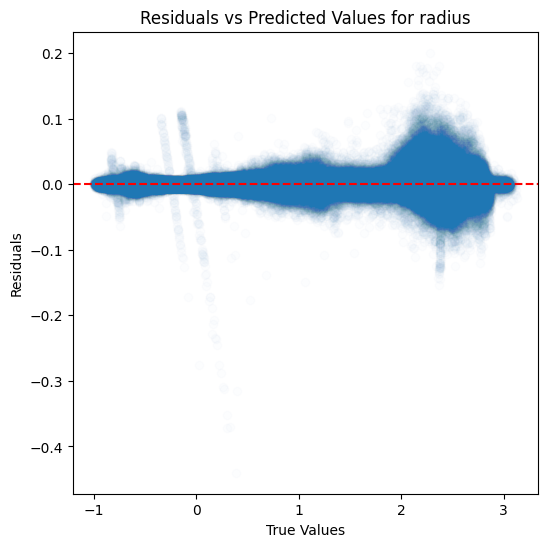

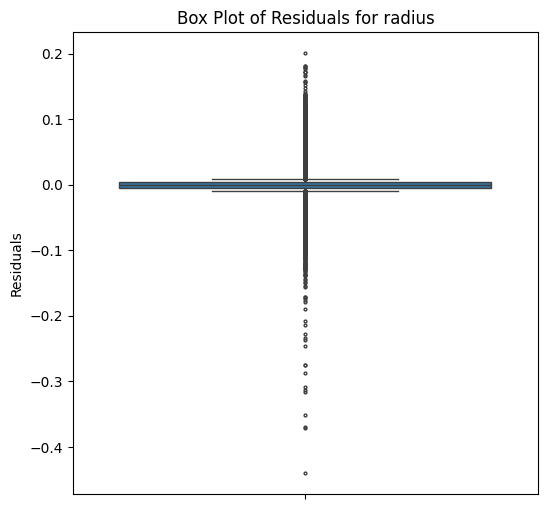

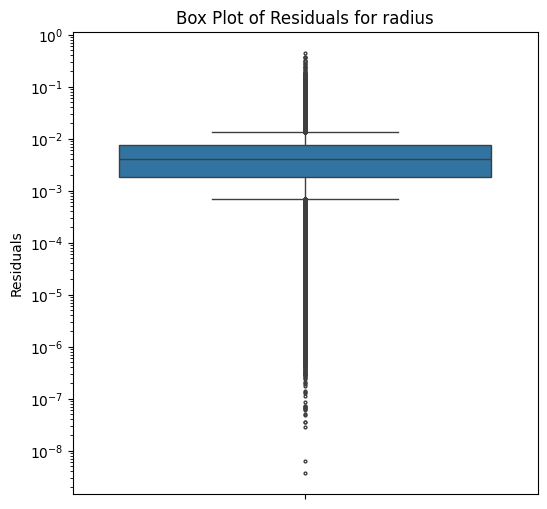

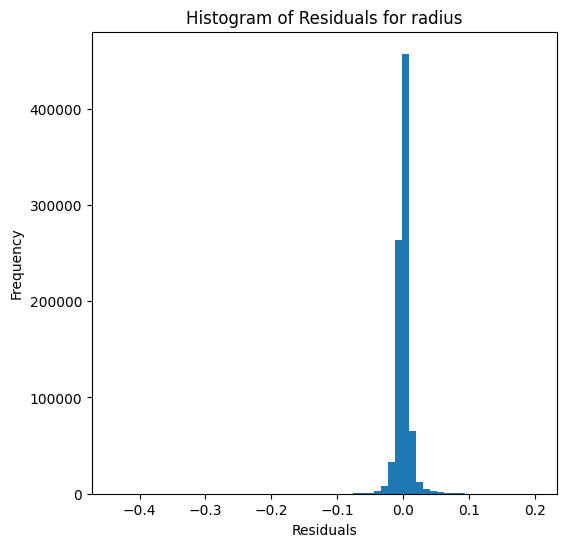

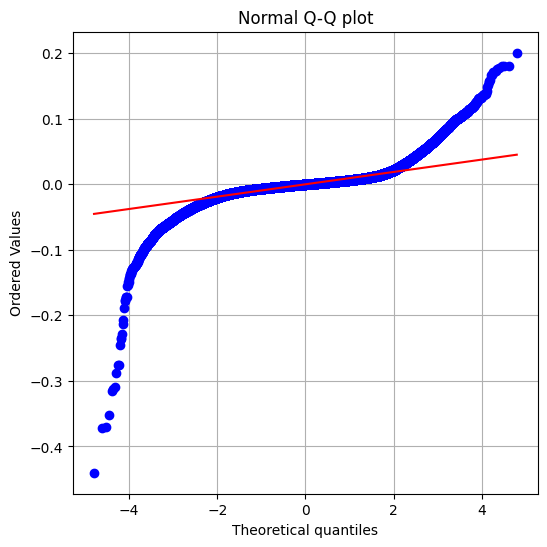

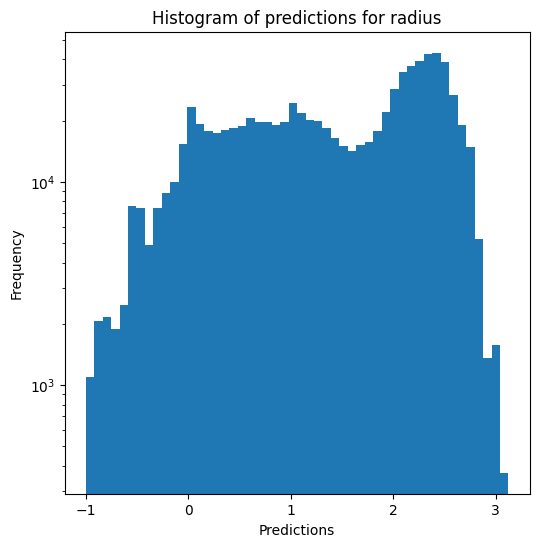

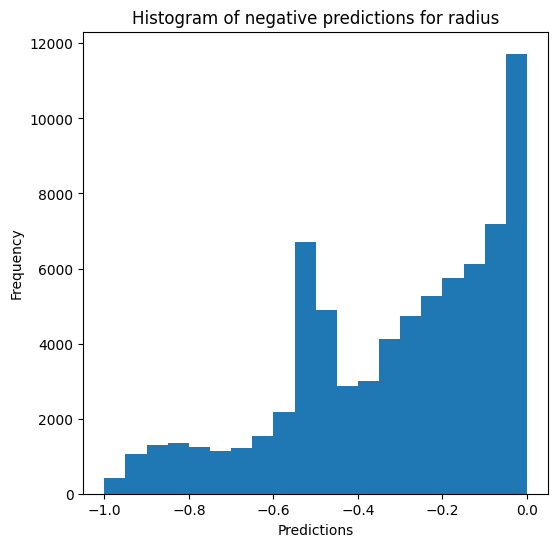

In [8]:
best_params_XGB = {'booster': 'gbtree', 'n_estimators': 600, 'max_depth': 10, 'min_child_weight': 11, 'gamma': 0, 'subsample': 1}

print(path_to_results)
xgb_evaluator = Model_evaluator("XGBoost", path=path_to_results, physical_model=physical_model, output_parameters=["mass", "radius"])
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, path_to_predictions, tag, random_state=12, override=True, use_preds=False, n_jobs=10, **best_params_XGB)

In [11]:
# saving the model to test the topology with a better model than base XGB
import joblib

best_params_XGB = {'booster': 'gbtree', 'n_estimators': 600, 'max_depth': 10, 'min_child_weight': 11, 'gamma': 0, 'subsample': 1}
xgb_mdl = XGBRegressor(**best_params_XGB)
xgb_mdl.fit(X_train, y_train)
joblib.dump(xgb_mdl, '../../../../../../../model/fully_trained/primary_XGB.pkl')

['../../../../../../../model/fully_trained/primary_XGB.pkl']